# 201_01 — Simulación y preprocesamiento · Escenario: GARCH en los scores

Paso **1 de 5** del ciclo `Python → MATLAB → Python`:
- 01: **este notebook** genera los datos, toma la base de Fourier del generador como representación (**scores crudos, sin estandarizar**) y escribe los datasets AR
- 02: `psbp_fd_iteracion.m` muestreo MCMC en MATLAB, sólo con el bloque de entrenamiento
- 03, 04, 05: `201_03_convergencia` / `201_04_evaluacion` / `201_05_comparacion`

Las celdas marcadas **`[CONFIG]`** son las únicas que se tocan al cambiar de experimento.



## 1. Imports y rutas

In [9]:
import json
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Generadores y contrato de artefactos
from model_psbp_fd.pipelines import (
    ConfigEscenarioGARCH, generar_escenario_GARCH,
    guardar_escenario,
    guardar_curvas, guardar_representacion
)
# Preprocesamiento funcional
from model_psbp_fd.functions_models import (
    FunctionalRepresentation, FPCA_L2
)
from model_psbp_fd.fit.preparacion_barrido import preparar_punto
# Rutas del contrato y convención del EXPERIMENT_ID: el gemelo Python de
# config_paths.m. Antes esta sección armaba el dict PATHS a mano.
from model_psbp_fd.utils import (
    get_project_root, experiment_id, normalizar_lista_M,
    rutas_por_M, guardar_en_todos, replicar_figura
)
from model_psbp_fd.graphics import (
    plot_empirical_sample, plot_mean_and_variance, plot_fts_empirical,
    plot_series_componentes,
    plot_diagnostico_rezagos
)

plt.style.use("seaborn-v0_8-darkgrid")
%matplotlib inline


### 1.1 `[CONFIG]` Identificación del experimento y barrido en $M$

In [ ]:
PROJECT_ROOT = get_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Variantes de la 201 (una por defecto). Se corre este notebook UNA VEZ POR VARIANTE.
VARIANTES = {
    # Chung §4.2 en escala cruda con gating mas libre (taupsij_z = 10, sd psi 0.32 en z).
    "chungEscG": {"hiperparametros": "chung_escala_cruda", "N": 30, "taupsij_z": 10.0},
    # Control opcional: el prior de psi del paper (taupsij_z = 100).
    "chungEsc":  {"hiperparametros": "chung_escala_cruda", "N": 30},
}
VARIANTE = "chungEscG"

VAR_CFG      = {"covariables": "propio", **VARIANTES[VARIANTE]}
CRUZADOS     = VAR_CFG["covariables"] == "cruzados"
BASENAME     = f"escenario_201_{VARIANTE}"
ESCENARIO_ID = 1      # escenario GARCH en los scores (único)
REPLICA_ID   = 1      # réplica Monte Carlo
SEED         = 41232  # semilla base; MATLAB la LEE de hyperparameters.json

# Especificar componentes a estudiar 
M_FPCA_LIST = (1, 2, 3, 4, 5, 6, 7,8,9,10)

LIMPIAR_DIRECTORIOS = False

# FUnciones
M_FPCA_LIST     = normalizar_lista_M(M_FPCA_LIST)
M_ENTRENO       = max(M_FPCA_LIST)   # rezago propio: único M que se entrena (cruzados: todos)
EXPERIMENT_BASE = experiment_id(BASENAME, ESCENARIO_ID, REPLICA_ID)

print(f"PROJECT_ROOT    : {PROJECT_ROOT}")
print(f"EXPERIMENT_BASE : {EXPERIMENT_BASE}")
print(f"VARIANTE        : {VARIANTE}  {VAR_CFG}")
print(f"Escenario {ESCENARIO_ID} · réplica {REPLICA_ID} · seed base {SEED}")
print(f"barrido en M    : {list(M_FPCA_LIST)}   (se entrena solo M={M_ENTRENO})")
for _M in M_FPCA_LIST:
    print(f"   M={_M}  ->  {experiment_id(BASENAME, ESCENARIO_ID, REPLICA_ID, _M)}")


PROJECT_ROOT    : C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1
EXPERIMENT_BASE : escenario_201_chungEscG_1_r01
VARIANTE        : chungEscG  {'covariables': 'propio', 'hiperparametros': 'chung_escala_cruda', 'N': 30, 'taupsij_z': 10.0}
Escenario 1 · réplica 1 · seed base 41232
barrido en M    : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]   (se entrena solo M=10)
   M=1  ->  escenario_201_chungEscG_1_r01_m01
   M=2  ->  escenario_201_chungEscG_1_r01_m02
   M=3  ->  escenario_201_chungEscG_1_r01_m03
   M=4  ->  escenario_201_chungEscG_1_r01_m04
   M=5  ->  escenario_201_chungEscG_1_r01_m05
   M=6  ->  escenario_201_chungEscG_1_r01_m06
   M=7  ->  escenario_201_chungEscG_1_r01_m07
   M=8  ->  escenario_201_chungEscG_1_r01_m08
   M=9  ->  escenario_201_chungEscG_1_r01_m09
   M=10  ->  escenario_201_chungEscG_1_r01_m10


In [11]:
PATHS_POR_M = rutas_por_M(BASENAME, ESCENARIO_ID, REPLICA_ID, M_FPCA_LIST,
                          dominio="simulaciones", project_root=PROJECT_ROOT,
                          limpiar=LIMPIAR_DIRECTORIOS)

for M, p in PATHS_POR_M.items():
    print(f"M={M}  ({experiment_id(BASENAME, ESCENARIO_ID, REPLICA_ID, M)})")
    for nombre, ruta in p.items():
        print(f"  {nombre:12s} -> {ruta}")

M=1  (escenario_201_chungEscG_1_r01_m01)
  raw          -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\raw\escenario_201_chungEscG_1_r01_m01
  functional   -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\processed\functional\escenario_201_chungEscG_1_r01_m01
  predict      -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\processed\predict\escenario_201_chungEscG_1_r01_m01
  out_report   -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\reports\simulaciones\escenario_201_chungEscG_1_r01_m01
  out_artefact -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\artefact\simulaciones\escenario_201_chungEscG_1_r01_m01
M=2  (escenario_201_chungEscG_1_r01_m02)
  raw          -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\raw\escenario_201_chungEscG_1_r01_m02
  functional   -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\s

### 2.1 `[CONFIG]` Parámetros del generador

`sim_escenario_GARCH` (anexo, algoritmo C-1): $X_t(\tau)=\mu(\tau)+\sum_{j=1}^{10}\xi_{tj}\varphi_j(\tau)$ con la base de Fourier y $\mu(\tau)=\sin(2\pi\tau)$. Cada score activo $j=1..4$ sigue un AR(1) con innovaciones GARCH(1,1):

$$u_{tj}=\phi\,u_{t-1,j}+a_{tj},\quad a_{tj}=\sqrt{h_{tj}}\,\varepsilon_{tj},\quad h_{tj}=\alpha_0+\alpha_1 a_{t-1,j}^2+\beta_1 h_{t-1,j},$$

con $\phi=0.5$, $\alpha_1=0.25$, $\beta_1=0.60$, $\sigma_a^2=1$. **La media condicional es lineal** ($\phi u_{t-1}$) y la no linealidad está sólo en la **varianza**, con memoria de $1/(1-\alpha_1-\beta_1)\approx 6.7$ curvas. $\xi_5..\xi_{10}$ son AR(1) pasivos de coeficiente 0.3.

Con rezago propio, $h_t$ no es observable por completo ($\beta_1$ arrastra la historia), pero $a_{t-1}=u_{t-1}-\phi u_{t-2}$ es función de los dos rezagos propios más próximos, de modo que con $N_{lags}\ge2$ el término $\alpha_1 a_{t-1}^2$ sí puede aprenderse. Se espera ventaja en el **Bloque B** (calibración) y empate en el A. Valores y control de calidad: docstring de `pipelines/sim_escenario_GARCH.py`. La varianza condicional vive en `salida.internos`: **no** se entrega a la estimación.


In [12]:
# ── Parámetros fijos del estudio (comunes a los escenarios) ─────────────────
L_GRILLA   = 75     # puntos de la grilla
T_CURVAS   = 1000   # curvas retenidas tras el calentamiento
PROP_TRAIN = 0.70   # proporción del bloque de entrenamiento
SIGMA_OBS  = 0.0    # sin ruido de medición: los scores son el insumo

SIM_CFG = ConfigEscenarioGARCH(
    L         = L_GRILLA,
    T         = T_CURVAS,
    burn_in   = 300,         
    sigma_obs = SIGMA_OBS,
    R         = 1,            # una réplica por corrida; el barrido usa REPLICA_ID
    seed      = SEED,
    # J, n_rezagos, lambda_1, rho: valores del módulo (sim_escenario_GARCH.py)
    prop_train_referencia = PROP_TRAIN,
)

for k, v in SIM_CFG.to_dict().items():
    print(f"  {k:<24}: {v}")


  L                       : 75
  T                       : 1000
  burn_in                 : 300
  sigma_obs               : 0.0
  R                       : 1
  seed                    : 41232
  media_fn                : media_seno
  jitter                  : 1e-10
  J                       : 10
  n_rezagos               : 2
  lambda_1                : 0.5
  rho                     : 0.55
  prop_train_referencia   : 0.7


### 2.2 Generación

In [13]:
salida = generar_escenario_GARCH(SIM_CFG)

REPLICA_IDX = REPLICA_ID - 1
X_raw  = salida.observaciones[REPLICA_IDX]   # (T, G) = X_true: sigma_obs = 0, no hay ruido de medición
X_true = salida.curvas[REPLICA_IDX]          # (T, G) VERDADERA — sólo referencia
grilla = salida.grilla
T, G   = X_raw.shape

print(f"Observadas {X_raw.shape} · verdaderas {X_true.shape} · grilla {grilla.shape}")
print(f"Ruido de medición efectivo: sd(X_raw - X_true) = {(X_raw - X_true).std():.4f}"
      f"   (nominal {SIGMA_OBS})")
print("\nControl de calidad del generador:")
for k, v in salida.diagnostico.items():
    print(f"  {k:32s} = {v}")


Observadas (1000, 75) · verdaderas (1000, 75) · grilla (75,)
Ruido de medición efectivo: sd(X_raw - X_true) = 0.0000   (nominal 0.0)

Control de calidad del generador:
  n_replicas                       = 1
  n_curvas                         = 1000
  n_puntos_grilla                  = 75
  todo_finito                      = True
  media_empirica_global            = 0.0006149542911307713
  media_ee_montecarlo              = nan
  var_puntual_media                = 1.0619233684778404
  var_puntual_min                  = 0.8628780839648034
  var_puntual_max                  = 1.2230590424935888
  acf1_media                       = 0.49598561984440465
  acf1_ee_montecarlo               = nan
  razon_senal_ruido                = inf
  n_rezagos                        = 2
  r2_oraculo_por_componente        = [0.22154587924867353, 0.28897106197881406, 0.2825387882451662, 0.3202511791012873, 0.11391621288223941]
  r2_ar_propio_por_componente      = [0.22399290874361122, 0.2912193223912005, 0.2

In [14]:
for _M, _p in PATHS_POR_M.items():
    simulation_config = {
        "sim_params":    salida.config.to_dict(),
        "diagnostico":   salida.diagnostico,
        "replica_idx":   REPLICA_IDX,
        "experiment_id": experiment_id(BASENAME, ESCENARIO_ID, REPLICA_ID, _M),
        "escenario_id":  int(ESCENARIO_ID),
        "replica_id":    int(REPLICA_ID),
        "m_fpca":        int(_M),
        "m_fpca_list":   [int(m) for m in M_FPCA_LIST],
        "seed":          SEED,
        "T": int(T), "G": int(G),
    }
    with open(_p["raw"] / "simulation_config.json", "w", encoding="utf-8") as f:
        json.dump(simulation_config, f, indent=2, ensure_ascii=False)

    _npz = guardar_escenario(salida, str(_p["raw"] / f"escenario_{ESCENARIO_ID}"),
                             incluir_curvas=True, incluir_internos=True)
    print(f"[raw · M={_M}] simulation_config.json  ·  {_npz}")

[raw · M=1] simulation_config.json  ·  C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\raw\escenario_201_chungEscG_1_r01_m01\escenario_1.npz
[raw · M=2] simulation_config.json  ·  C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\raw\escenario_201_chungEscG_1_r01_m02\escenario_1.npz
[raw · M=3] simulation_config.json  ·  C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\raw\escenario_201_chungEscG_1_r01_m03\escenario_1.npz
[raw · M=4] simulation_config.json  ·  C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\raw\escenario_201_chungEscG_1_r01_m04\escenario_1.npz
[raw · M=5] simulation_config.json  ·  C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\raw\escenario_201_chungEscG_1_r01_m05\escenario_1.npz
[raw · M=6] simulation_config.json  ·  C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\raw\escenario_201_chungEscG_

### 2.3 Visualización de los datos

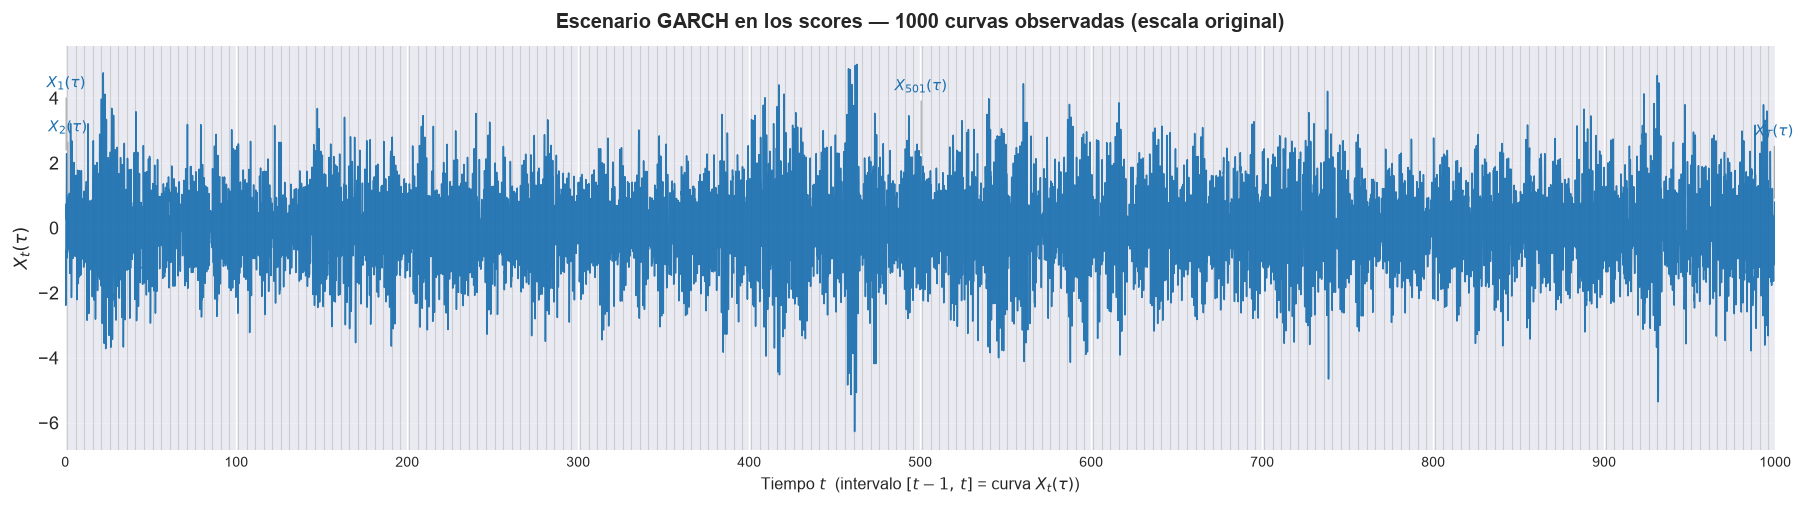

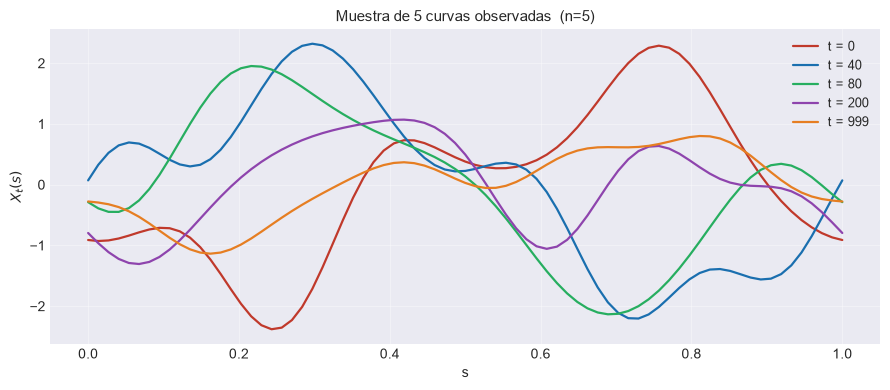

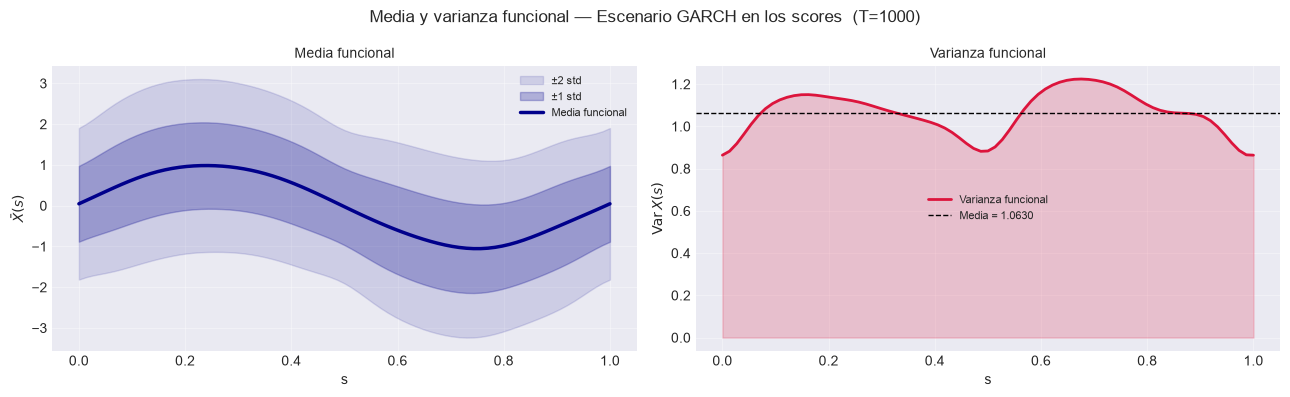

In [15]:
highlight_idx = [0, 1, T // 2, T - 1]

plot_fts_empirical(
    X_raw, grilla, highlight_idx=highlight_idx, separator_every=5,
    title=f"Escenario GARCH en los scores — {T} curvas observadas (escala original)")
replicar_figura("01_fts_empirica_raw.png", PATHS_POR_M)
plt.show()

plot_empirical_sample(
    X_raw, grilla, sample_idx=[0, 40, 80, 200, T - 1],
    title="Muestra de 5 curvas observadas")
replicar_figura("02_muestra_empirica_raw.png", PATHS_POR_M)
plt.show()

plot_mean_and_variance(
    X_raw, grilla, show_std1=True, show_std2=True,
    title="Media y varianza funcional — Escenario GARCH en los scores")
replicar_figura("03_media_varianza_raw.png", PATHS_POR_M)
plt.show()

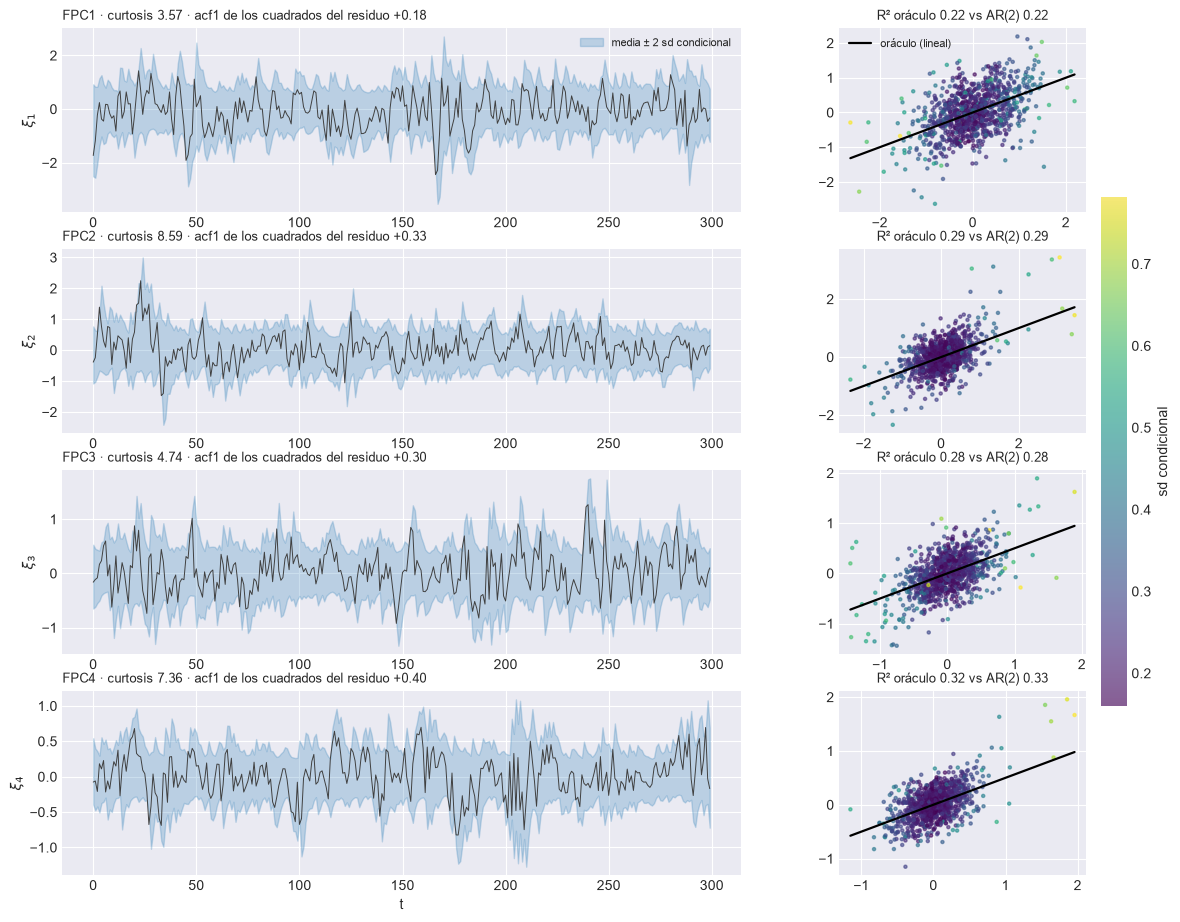

memoria nominal de la volatilidad : 7 curvas
R^2 L2 oráculo / lineal           : 0.2479 / 0.2646   (media lineal: brecha ~ 0)
heterocedasticidad (q4/q1 de |xi|) : [1.89 2.28 1.6  1.9 ]
|cos| ejes (scores verd.)         : [0.974 0.974 0.992 0.992 0.999 0.998]


In [16]:
# Scores verdaderos xi (SON el insumo) y volatilidad condicional (no se entrega).
XI_true = salida.internos["scores"][REPLICA_IDX]
MC_true = salida.internos["media_condicional"][REPLICA_IDX]
SD_c    = np.sqrt(salida.internos["var_condicional"][REPLICA_IDX]) * salida.internos["escala_scores"][:4]
_d, _n  = salida.diagnostico, 300

fig, axes = plt.subplots(4, 2, figsize=(14, 11), gridspec_kw={"width_ratios": [2.2, 1]})
for j in range(4):
    a, b = axes[j]
    t_ = np.arange(_n)
    a.fill_between(t_, (MC_true[:, j] - 2 * SD_c[:, j])[:_n], (MC_true[:, j] + 2 * SD_c[:, j])[:_n],
                   color="#2c7fb8", alpha=0.25, label="media ± 2 sd condicional")
    a.plot(t_, XI_true[:_n, j], color="0.25", lw=0.7)
    a.set_ylabel(rf"$\xi_{j+1}$")
    a.set_title(f"FPC{j+1} · curtosis {_d['curtosis_scores_activos'][j]:.2f} · "
                f"acf1 de los cuadrados del residuo {_d['acf1_cuadrados_residuo'][j]:+.2f}",
                fontsize=9, loc="left")
    sc = b.scatter(XI_true[:-1, j], XI_true[1:, j], s=5, alpha=0.6, c=SD_c[1:, j], cmap="viridis")
    g = np.linspace(XI_true[:-1, j].min(), XI_true[:-1, j].max(), 100)
    b.plot(g, salida.internos["parametros"]["phi"] * g, "k", lw=1.6, label="oráculo (lineal)")
    b.set_title(f"R² oráculo {_d['r2_oraculo_por_componente'][j]:.2f} vs AR(2) "
                f"{_d['r2_ar_propio_por_componente'][j]:.2f}", fontsize=9)
    if j == 0:
        a.legend(fontsize=8); b.legend(fontsize=8)
fig.colorbar(sc, ax=axes[:, 1], shrink=0.6, label="sd condicional")
axes[-1, 0].set_xlabel("t")
replicar_figura("04b_mecanismo_scores.png", PATHS_POR_M, fig=fig)
plt.show()

print(f"memoria nominal de la volatilidad : {_d['memoria_volatilidad']:.0f} curvas")
print(f"R^2 L2 oráculo / lineal           : {_d['r2_oraculo']:.4f} / {_d['r2_lineal']:.4f}   (media lineal: brecha ~ 0)")
print(f"heterocedasticidad (q4/q1 de |xi|) : {np.round(_d['heterocedasticidad_q4_q1'], 2)}")
print(f"|cos| ejes (scores verd.)         : {np.round(_d['cos_ejes_scores'][:6], 3)}")

### 2.4 Persistencia de curvas

Se guardan las dos matrices con nombres distintos (`X_curves.npy` y
`X_curves_true.npy`) para que no puedan confundirse aguas abajo.

In [17]:
_p = guardar_en_todos(guardar_curvas, PATHS_POR_M, X_raw, grilla, X_true=X_true)
for clave, ruta in _p.items():
    print(f"[functional] {clave:12s} -> {ruta.name}"
          f"   (replicado en {len(PATHS_POR_M)} directorios)")

[functional] curvas       -> X_curves.npy   (replicado en 10 directorios)
[functional] grilla       -> domain_grid.npy   (replicado en 10 directorios)
[functional] curvas_true  -> X_curves_true.npy   (replicado en 10 directorios)


### 2.5 Partición temporal

Todo objeto **estimado a partir de los datos** —los autovalores de la FPCA y el
estandarizador, que aquí queda en identidad— se ajusta sólo con $\{1,\dots,T_0\}$ y se aplica al bloque de
prueba mediante `transform`.

In [18]:
T0 = int(np.floor(PROP_TRAIN * T))
assert 10 < T0 < T, f"T0={T0} fuera de rango para T={T}."

idx_train, idx_test = np.arange(0, T0), np.arange(T0, T)
X, X_train, X_test = X_raw, X_raw[idx_train], X_raw[idx_test]

print(f"entrenamiento : t ∈ [1, {T0}]      → {X_train.shape}")
print(f"prueba        : t ∈ [{T0+1}, {T}]  → {X_test.shape}")
print(f"proporción    : {T0/T:.1%} / {1 - T0/T:.1%}")

entrenamiento : t ∈ [1, 700]      → (700, 75)
prueba        : t ∈ [701, 1000]  → (300, 75)
proporción    : 70.0% / 30.0%


## 3. Representación funcional: base de Fourier del generador

Los scores son el insumo de los modelos que los usan, y los coeficientes de la curva se proyectan con **todos** los scores: la base es la de Fourier del generador, ortonormal en $L^2$, de modo que $\theta_t=\mu_\theta+\xi_t$ y la Gram es la identidad. **No hay GCV, ni B-spline, ni FPCA estimada.**

### 3.1 Base conocida y coeficientes

`FunctionalRepresentation.desde_base` no ajusta nada: proyecta con la base del generador. Como $\mu(\tau)=\sin(2\pi\tau)=\varphi_1/\sqrt2$ cae en la base, la representación es **exacta** y el objetivo `curva_suavizada` coincide con la curva verdadera.

In [19]:
Phi_base = salida.internos["Phi"]                 # (G, J) Fourier del generador, ortonormal en L2
MU_THETA = salida.internos["mu_theta"]            # (J,) proyeccion de mu en la base

fr          = FunctionalRepresentation.desde_base(Phi_base, grilla)
THETA       = fr.transform(X, grilla)             # (T, K = J): mu_theta + xi
THETA_train = THETA[idx_train]
X_SUAV      = fr.reconstruct(THETA)               # objetivo de evaluacion (docs 03_05_00)

assert np.allclose(THETA, MU_THETA + XI_true, atol=1e-10), "theta debe ser mu_theta + xi."
print(f"THETA {THETA.shape}  (train={T0}, test={T - T0})")
print(f"|Gram - I|_max               = {np.abs(fr.gram_ - np.eye(fr.K_)).max():.2e}")
print(f"max|theta - (mu_theta + xi)| = {np.abs(THETA - (MU_THETA + XI_true)).max():.2e}")
print(f"MISE(suavizada, verdadera)   = {float((((X_SUAV - X_true)**2).mean(1)).mean()):.2e}")

guardar_en_todos(guardar_representacion, PATHS_POR_M, fr, THETA,
    extra={"T0": int(T0), "prop_train": float(PROP_TRAIN), "ajustado_en": "ninguno (base conocida)",
           "center": False, "n_basis": int(fr.K_), "order": None,
           "base": "fourier_generador"})
print(f"[functional] functional_representation.pkl + theta.csv + fr_config.json"
      f"   (replicado en {len(PATHS_POR_M)} directorios)")

THETA (1000, 10)  (train=700, test=300)
|Gram - I|_max               = 6.66e-16
max|theta - (mu_theta + xi)| = 1.78e-15
MISE(suavizada, verdadera)   = 2.59e-31
[functional] functional_representation.pkl + theta.csv + fr_config.json   (replicado en 10 directorios)


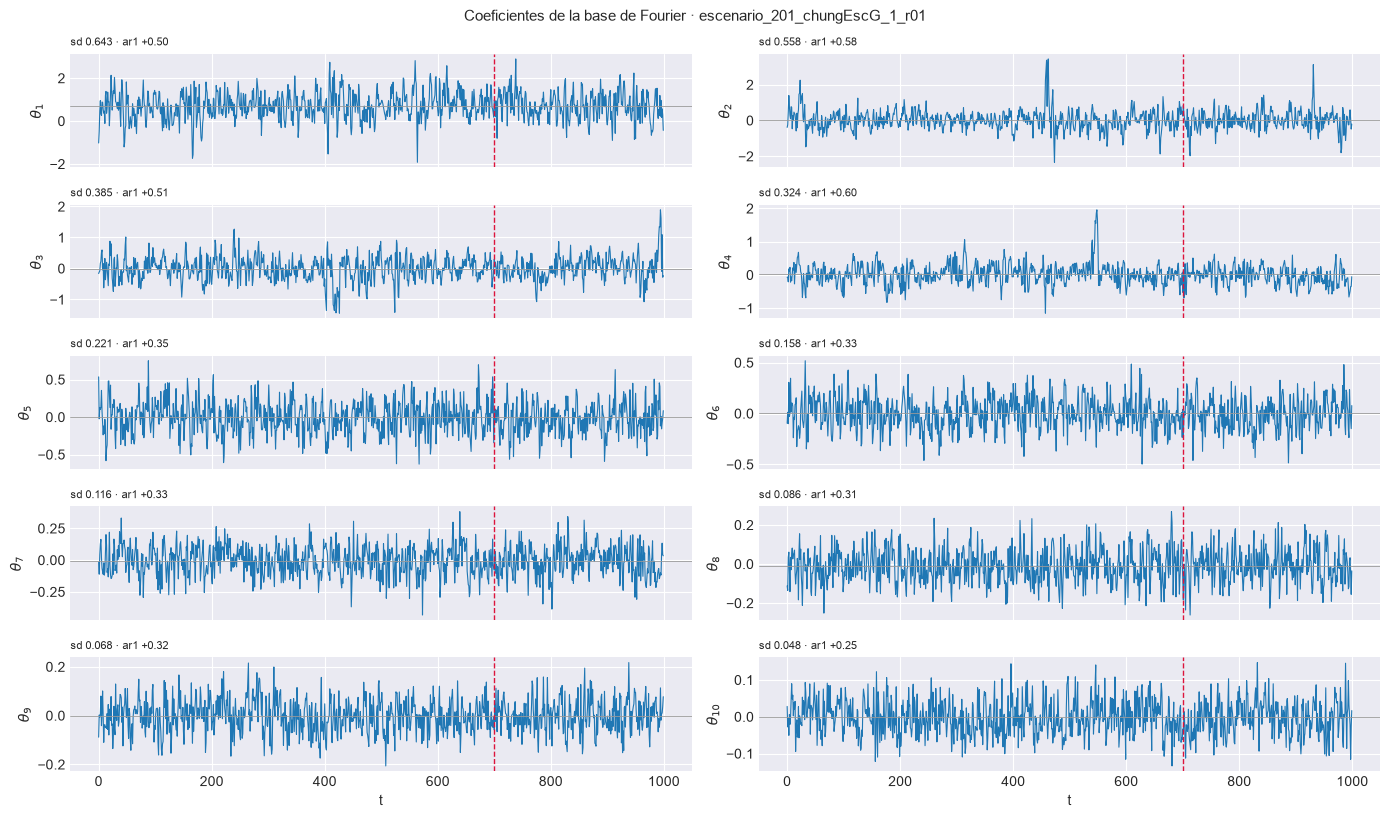

In [20]:
# Un panel por coeficiente theta_j = mu_theta + xi_j (la media funcional solo corre el nivel de theta_1).
fig = plot_series_componentes(
    THETA, T0=T0, simbolo=r"\theta",
    titulo=f"Coeficientes de la base de Fourier · {EXPERIMENT_BASE}")
replicar_figura("06_series_coeficientes.png", PATHS_POR_M, fig=fig)
plt.show()

### 3.2 FPCA de oráculo

La FPCA **no estima**: sus autofunciones son las $\varphi_j$ y sus scores los $\xi_{tj}$ del generador, en el orden de la base. Sólo los autovalores (varianza de cada score) se calculan con el bloque de entrenamiento. $K=J=10$ acota el barrido en $M$.

In [21]:
K = Phi_base.shape[1]
assert max(M_FPCA_LIST) <= K, (
    f"M_FPCA_LIST={list(M_FPCA_LIST)} excede K = J = {K} scores del generador.")

fpca = FPCA_L2.desde_scores_conocidos(
    Phi_base, grilla, MU_THETA, XI_true[idx_train].var(axis=0, ddof=1), n_ajuste=T0)

_ver = fpca.verificar(fr=fr)      # identidades estructurales (sin THETA_train: no hubo ajuste)
print("Verificación FPCA de oráculo:")
for k, v in _ver.items():
    print(f"  {k:34s} = {v:.3e}" if isinstance(v, float) else f"  {k:34s} = {v}")
assert _ver["todo_ok"], "Las identidades estructurales de la FPCA de oráculo no se cumplen."

fpca.set_M(K)
assert np.allclose(fpca.transform(THETA), XI_true, atol=1e-10), "los scores deben ser xi."

VAR_TARGET = 0.95
M_SUGERIDO = fpca.seleccionar_M(VAR_TARGET)
print(f"\nK disponibles: {K}   ·   sugerencia (var ≥ {VAR_TARGET:.0%}): M = {M_SUGERIDO}")
for _M in M_FPCA_LIST:
    print(f"  M={_M}: var. acum = {fpca.var_cum[_M-1]:.4%}"
          + ("  ·  regla del 95 %" if _M == M_SUGERIDO else ""))

Verificación FPCA de oráculo:
  M                                  = 10
  K                                  = 10
  n_ajuste                           = 700
  cond_W                             = 1.000e+00
  err_ortonormalidad_L2              = 1.221e-15
  err_ortonormalidad_gram            = 1.665e-15
  var_explicada                      = 1.000e+00
  err_rutas_reconstruccion           = 8.882e-16
  err_linealidad_reconstruct         = 0.000e+00
  err_linealidad_reconstruct_rel     = 0.000e+00
  criterios_evaluados                = ['err_ortonormalidad_L2', 'err_ortonormalidad_gram', 'err_rutas_reconstruccion', 'err_linealidad_reconstruct_rel']
  todo_ok                            = True

K disponibles: 10   ·   sugerencia (var ≥ 95%): M = 5
  M=1: var. acum = 38.2736%
  M=2: var. acum = 67.1473%
  M=3: var. acum = 80.8462%
  M=4: var. acum = 90.5960%
  M=5: var. acum = 95.1228%  ·  regla del 95 %
  M=6: var. acum = 97.4358%
  M=7: var. acum = 98.6813%
  M=8: var. acum = 99.3628%
  M=

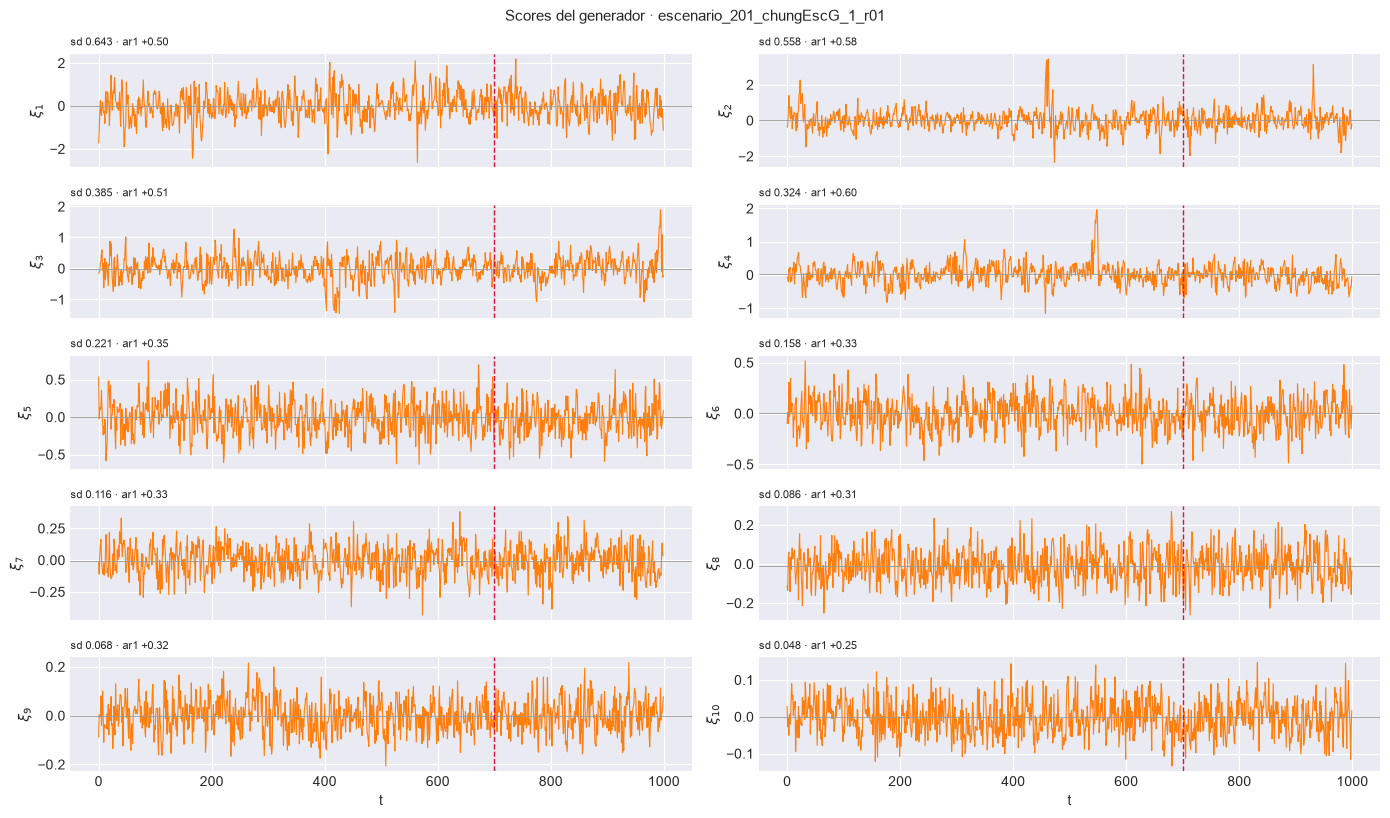

In [22]:
# Un panel por score xi_j, los J = K del generador (los que alimentan al modelo).
XI = fpca.transform(THETA)                       # (T, K), fpca con M = K
fig = plot_series_componentes(
    XI, T0=T0, simbolo=r"\xi", color="C1",
    titulo=f"Scores del generador · {EXPERIMENT_BASE}")
replicar_figura("07b_series_scores.png", PATHS_POR_M, fig=fig)
plt.show()

## 4. El bucle sobre `M_FPCA_LIST`

Se realiza:
- §4.1:`set_M(M)` y scores; contraste con la regla del 95 % 
- §4.2: estandarizador en **identidad** (los scores van crudos) y artefactos FPCA
- §4.3: diagnóstico de rezagos (Pearson y Spearman) sobre el bloque de entrenamiento
- §4.4: orden AR y construcción de los datasets
- §4.5: hiperparámetros y `mcmc_config` — el contrato con MATLAB
- §4.6: `eval_config`, líneas base y `verificar_contrato` 


In [23]:
# -- [CONFIG] Comunes a TODOS los puntos del barrido -------------------------
# Rezago propio: xi_(k,t) se predice con xi_(k,t-l), l = 1..N_LAGS. N_LAGS es
# el L del anexo: no es perilla.
N_LAGS = 4
assert N_LAGS >= SIM_CFG.n_rezagos, (
    f"N_LAGS={N_LAGS} < n_rezagos={SIM_CFG.n_rezagos} del simulador: el pipeline debe ver al menos los rezagos del generador.")

MCMC_CONFIG = {"nsim": 2500, "burn": 500, "N": VAR_CFG["N"], "M": 50}   # ojo: ese M es G*
N_CHAINS    = 3

HP_GLOBAL = {"atau": 0.5, "btau": 0.5, "ag": 0.5, "bg": 0.5,
             "mumu": 0.0, "taumu": 1.0, "pwj": 0.5}

# Chung §4.2 llevado a la escala cruda. Si x = sd*z, el prior del paper sobre z
# equivale a taupsij = taupsij_z*sd_x^2 y btau = 0.5*sd_y^2 (se aplican en
# procesar_punto). Inclusion: Chung en el lag 1, bpij = 5 del lag 2 en adelante.
HP_CHUNG_ESC = {"taupsij_z": float(VAR_CFG.get("taupsij_z", 100.0)), "btau_z": 0.5,
                "ab_por_lag": {l: (0.5, 0.5) if l == 1 else (0.5, 5.0)
                               for l in range(1, N_LAGS + 1)},
                "ab_cruzado": (0.5, 5.0)}
HP_BY_TYPE = {f"own_lag{l}": {"apij": HP_CHUNG_ESC["ab_por_lag"][l][0],
                              "bpij": HP_CHUNG_ESC["ab_por_lag"][l][1]}
              for l in range(1, N_LAGS + 1)}
# Cruzados (variante chungEscX): mismo prior de inclusion para todo rezago ajeno.
HP_BY_TYPE.update({f"cross_lag{l}": {"apij": HP_CHUNG_ESC["ab_cruzado"][0],
                                     "bpij": HP_CHUNG_ESC["ab_cruzado"][1]}
                   for l in range(1, N_LAGS + 1)})
print(f"VARIANTE {VARIANTE!r}: HP_GLOBAL={HP_GLOBAL}")
for _t, _v in HP_BY_TYPE.items():
    print(f"  {_t}: apij={_v['apij']}, bpij={_v['bpij']}  E[pi]={_v['apij'] / (_v['apij'] + _v['bpij']):.3f}")
print(f"N={MCMC_CONFIG['N']}  ·  mupsij=0, taupsij={HP_CHUNG_ESC['taupsij_z']:g}*sd_x^2, "
      "btau=0.5*sd_y^2 (Chung en escala cruda)")

# Lo común a todos los puntos del barrido: `preparar_punto` no recalcula nada de esto, y esa
# es la garantía de que los puntos comparten realización y base.
CTX = dict(
    PATHS_POR_M=PATHS_POR_M, BASENAME=BASENAME, ESCENARIO_ID=ESCENARIO_ID, REPLICA_ID=REPLICA_ID,
    SEED=SEED, fpca=fpca, THETA=THETA, idx_train=idx_train, idx_test=idx_test, T=T, T0=T0,
    PROP_TRAIN=PROP_TRAIN, N_LAGS=N_LAGS, CRUZADOS=CRUZADOS, M_ENTRENO=M_ENTRENO,
    M_SUGERIDO=M_SUGERIDO, HP_GLOBAL=HP_GLOBAL, HP_BY_TYPE=HP_BY_TYPE, HP_CHUNG_ESC=HP_CHUNG_ESC,
    VARIANTE=VARIANTE, VAR_CFG=VAR_CFG, MCMC_CONFIG=MCMC_CONFIG, N_CHAINS=N_CHAINS,
    X_SUAV=X_SUAV, grilla=grilla,
)

RESUMEN = [preparar_punto(M, CTX) for M in M_FPCA_LIST]


VARIANTE 'chungEscG': HP_GLOBAL={'atau': 0.5, 'btau': 0.5, 'ag': 0.5, 'bg': 0.5, 'mumu': 0.0, 'taumu': 1.0, 'pwj': 0.5}
  own_lag1: apij=0.5, bpij=0.5  E[pi]=0.500
  own_lag2: apij=0.5, bpij=5.0  E[pi]=0.091
  own_lag3: apij=0.5, bpij=5.0  E[pi]=0.091
  own_lag4: apij=0.5, bpij=5.0  E[pi]=0.091
  cross_lag1: apij=0.5, bpij=5.0  E[pi]=0.091
  cross_lag2: apij=0.5, bpij=5.0  E[pi]=0.091
  cross_lag3: apij=0.5, bpij=5.0  E[pi]=0.091
  cross_lag4: apij=0.5, bpij=5.0  E[pi]=0.091
N=30  ·  mupsij=0, taupsij=10*sd_x^2, btau=0.5*sd_y^2 (Chung en escala cruda)

M = 1   ·   escenario_201_chungEscG_1_r01_m01
M(95 %) segun la regla : 5   (K disponible = 10)
M de este punto        : 1   <- DIFIERE de la regla: es un punto de sensibilidad
M = 1   var. explicada = 38.2736%
[train] max|media xi| = 3.53e-03   (~ 0)
[test]  max|media xi| = 0.007
[test]  var xi / lambda = [0.978]
[holdout] ajustado con 700 filas = T0 (train[1:700]) -> ok=True

[functional] artefactos FPCA · cond_W = 1.000e+00
componentes

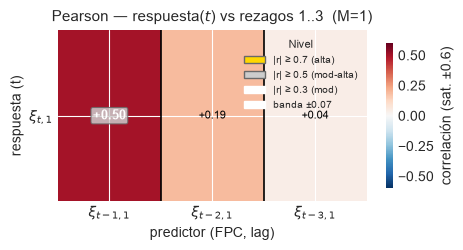

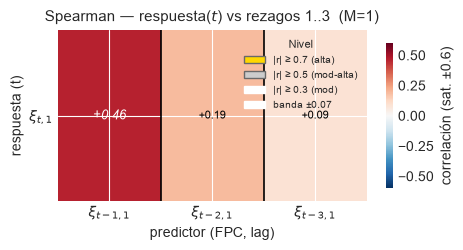

,n_test,RMSE_fpc1,RMSE_scores_prom,R2_scores_prom,MISE,RMSE_funcional
modelo,,,,,,
media_incondicional,300.0000,0.6349,0.6349,-0.0001,1.0277,1.0138
persistencia_lag1,300.0000,0.6931,0.6931,-0.1918,1.1050,1.0512


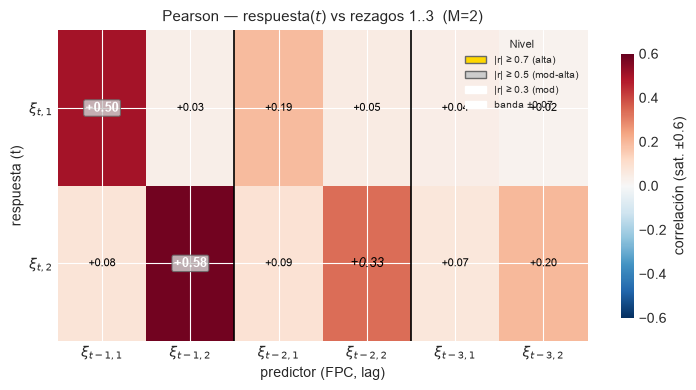

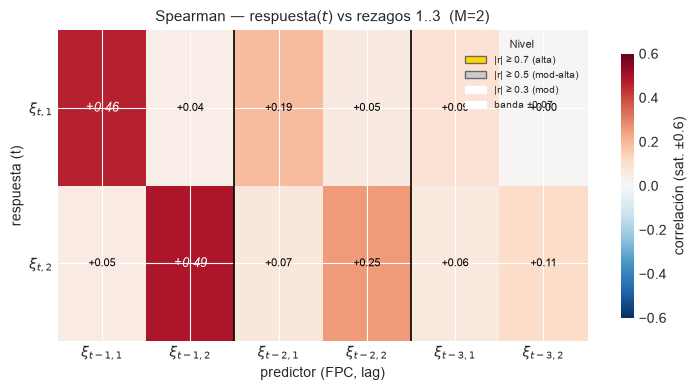

,n_test,RMSE_fpc1,RMSE_fpc2,RMSE_scores_prom,R2_scores_prom,MISE,RMSE_funcional
modelo,,,,,,,
media_incondicional,300.0000,0.6349,0.5512,0.5930,-0.0008,1.0277,1.0138
persistencia_lag1,300.0000,0.6931,0.5803,0.6367,-0.1510,1.1379,1.0667


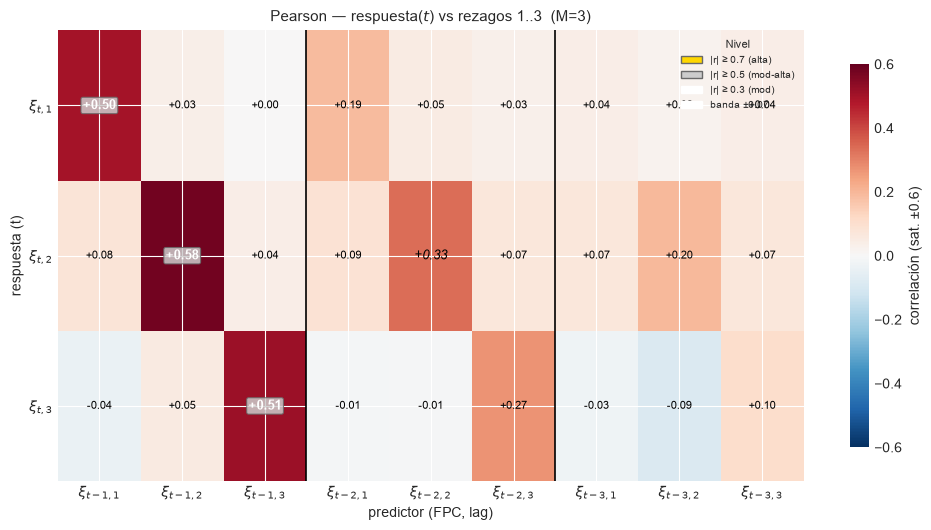

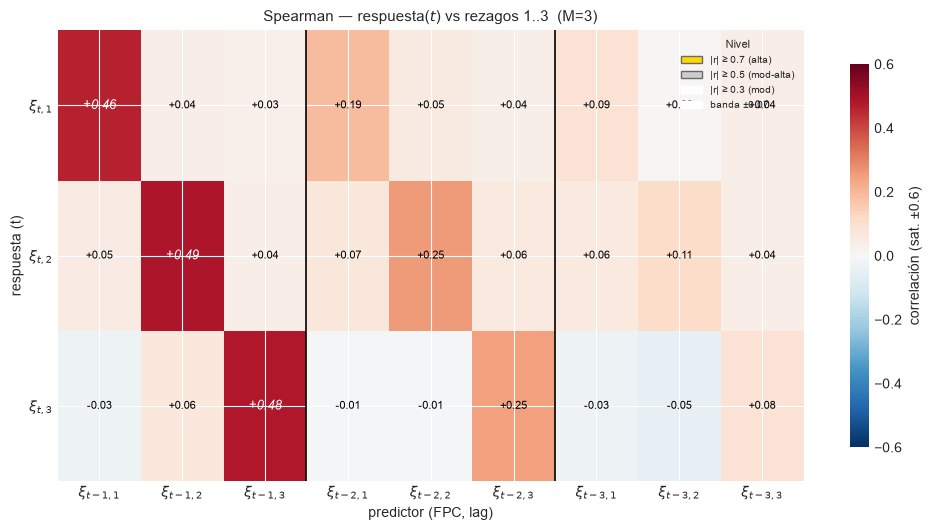

,n_test,RMSE_fpc1,RMSE_fpc2,RMSE_fpc3,RMSE_scores_prom,R2_scores_prom,MISE,RMSE_funcional
modelo,,,,,,,,
media_incondicional,300.0000,0.6349,0.5512,0.3878,0.5246,-0.0028,1.0277,1.0138
persistencia_lag1,300.0000,0.6931,0.5803,0.3588,0.5441,-0.0547,1.1164,1.0566


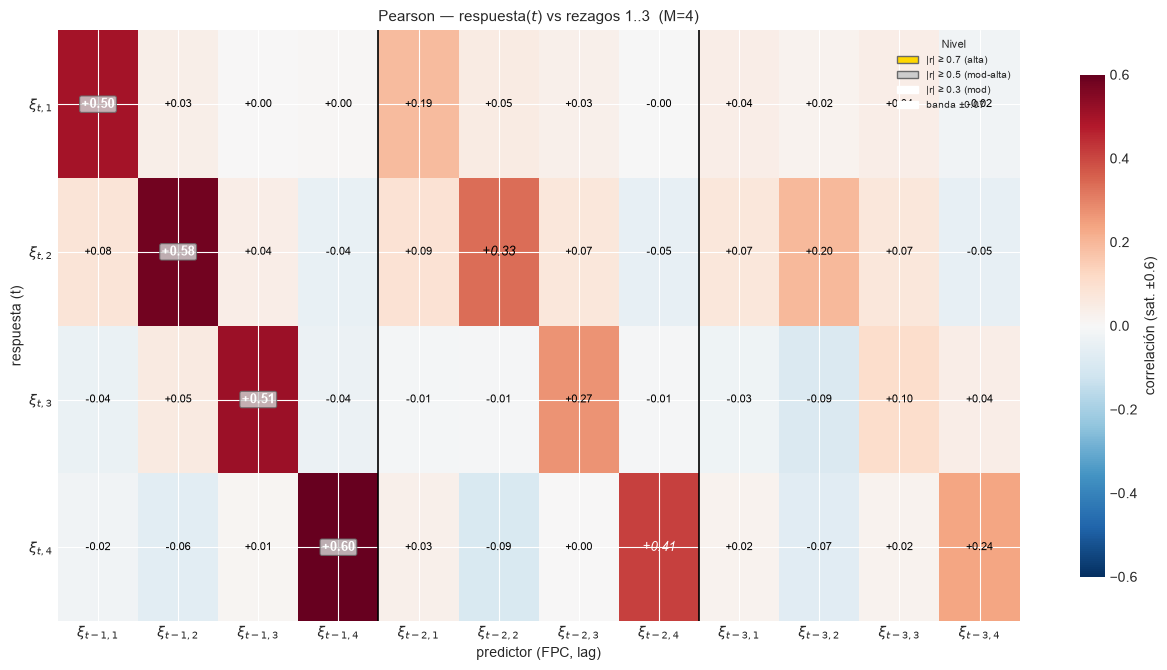

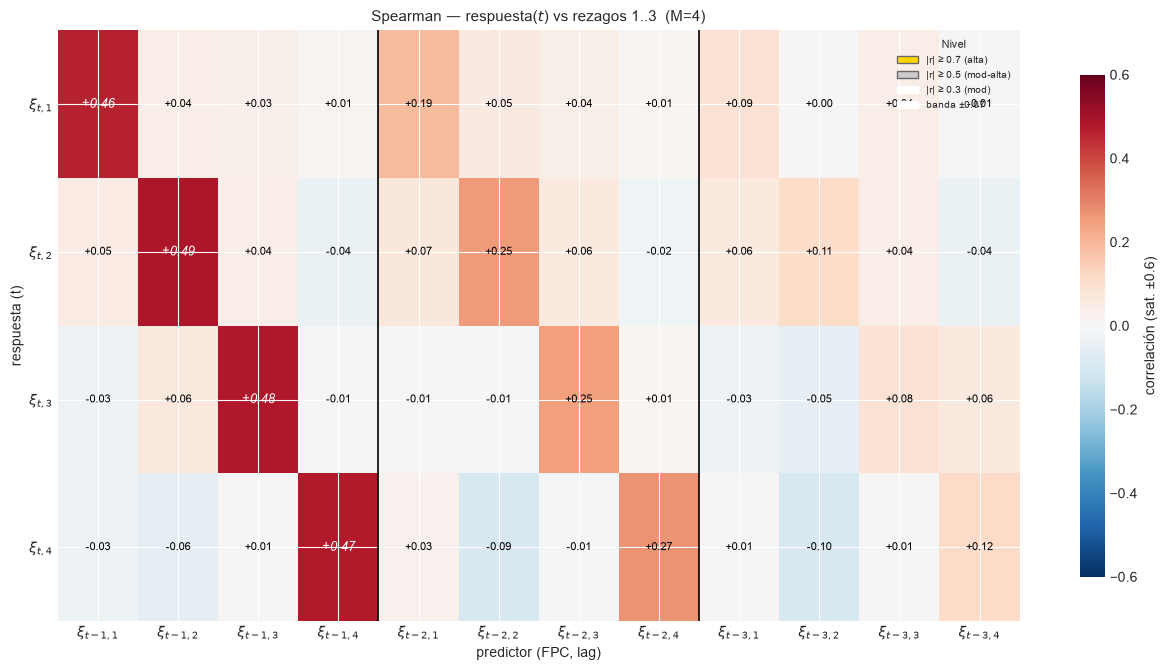

,n_test,RMSE_fpc1,RMSE_fpc2,RMSE_fpc3,RMSE_fpc4,RMSE_scores_prom,R2_scores_prom,MISE,RMSE_funcional
modelo,,,,,,,,,
media_incondicional,300.0000,0.6349,0.5512,0.3878,0.2718,0.4614,-0.0076,1.0277,1.0138
persistencia_lag1,300.0000,0.6931,0.5803,0.3588,0.2816,0.4785,-0.0654,1.1218,1.0592


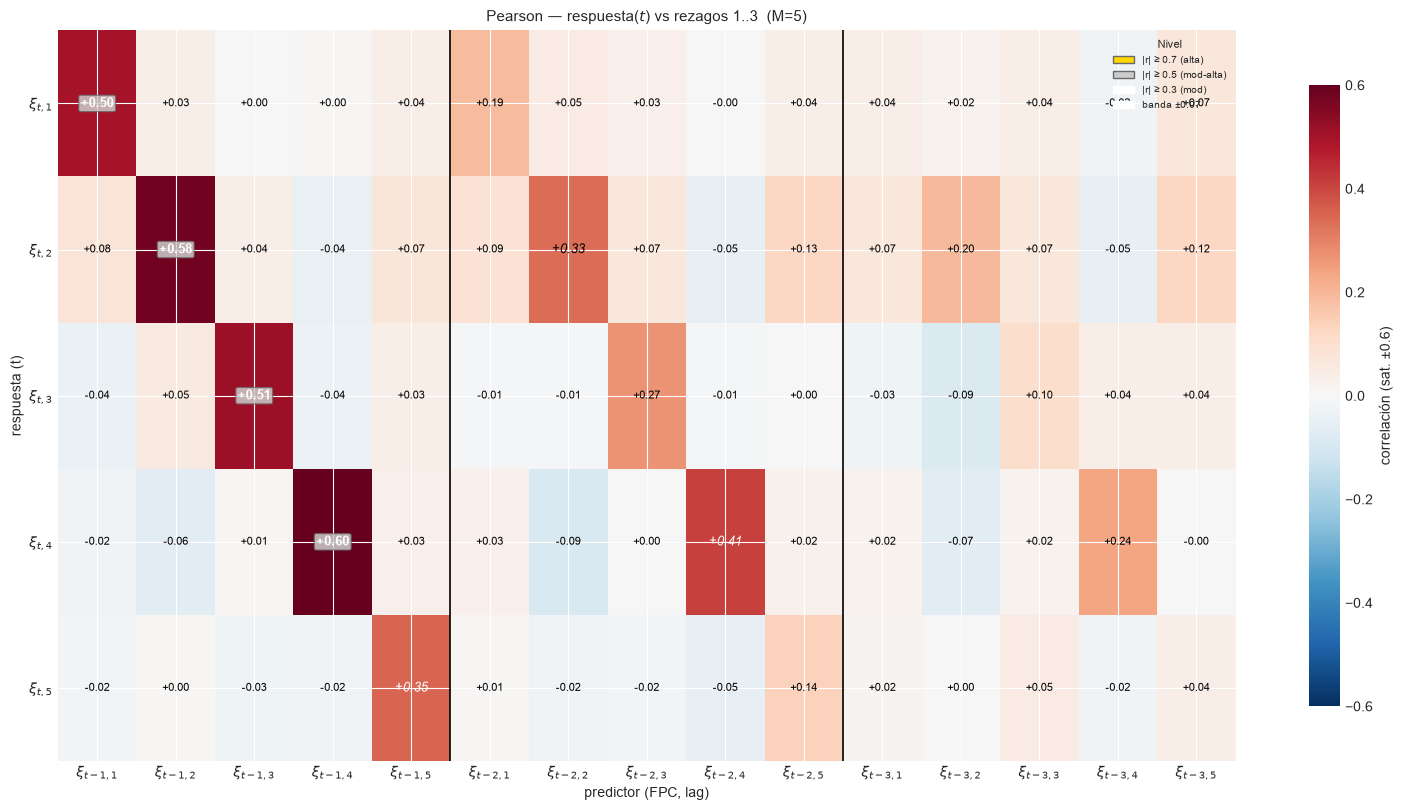

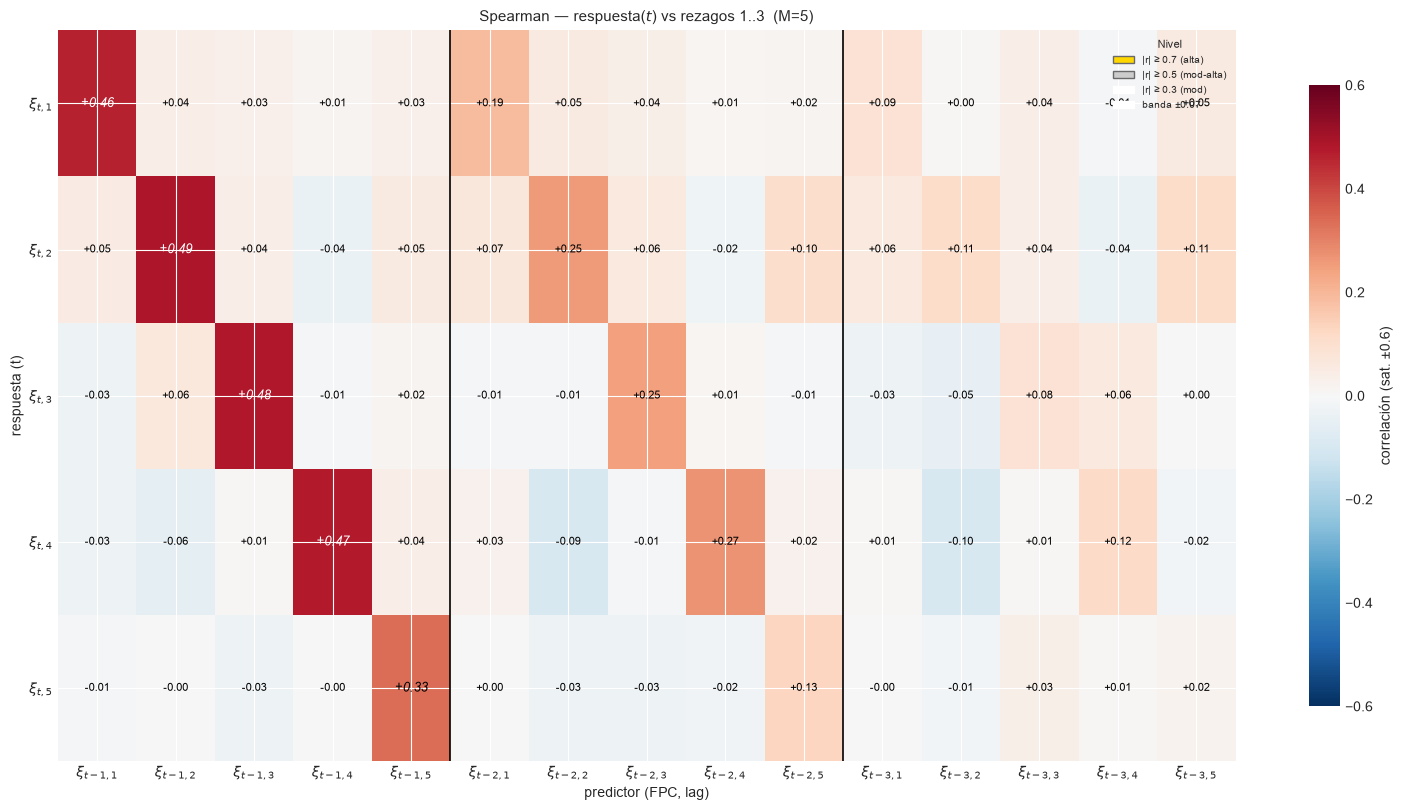

,n_test,RMSE_fpc1,RMSE_fpc2,RMSE_fpc3,RMSE_fpc4,RMSE_fpc5,RMSE_scores_prom,R2_scores_prom,MISE,RMSE_funcional
modelo,,,,,,,,,,
media_incondicional,300.0000,0.6349,0.5512,0.3878,0.2718,0.2082,0.4108,-0.0097,1.0277,1.0138
persistencia_lag1,300.0000,0.6931,0.5803,0.3588,0.2816,0.2431,0.4314,-0.1300,1.1376,1.0666


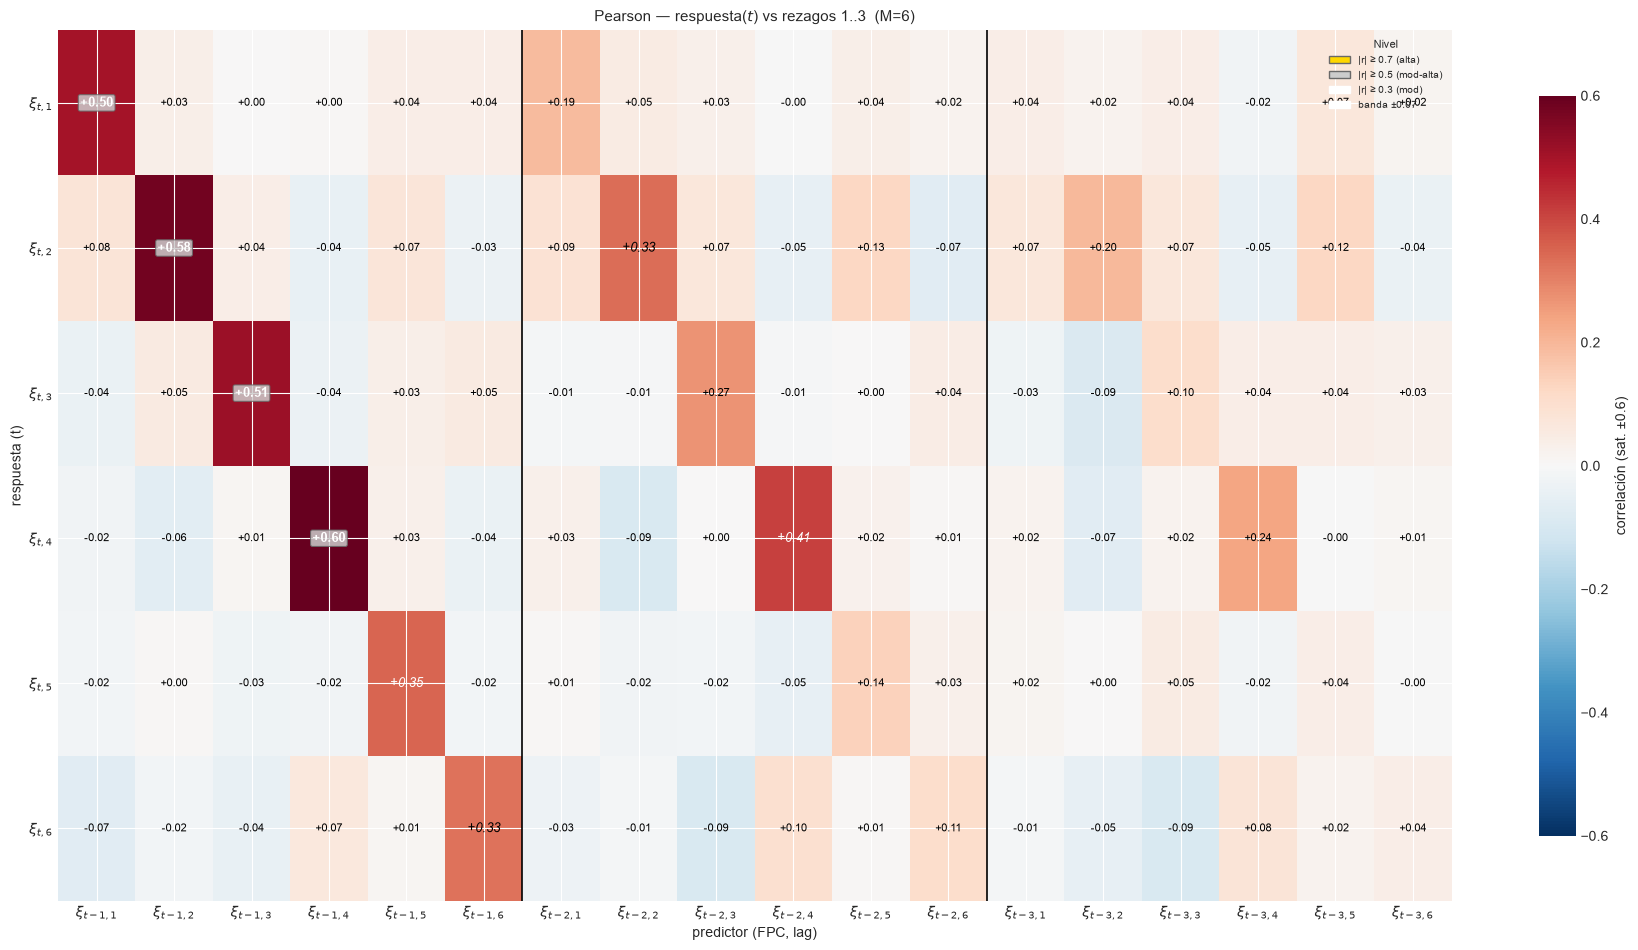

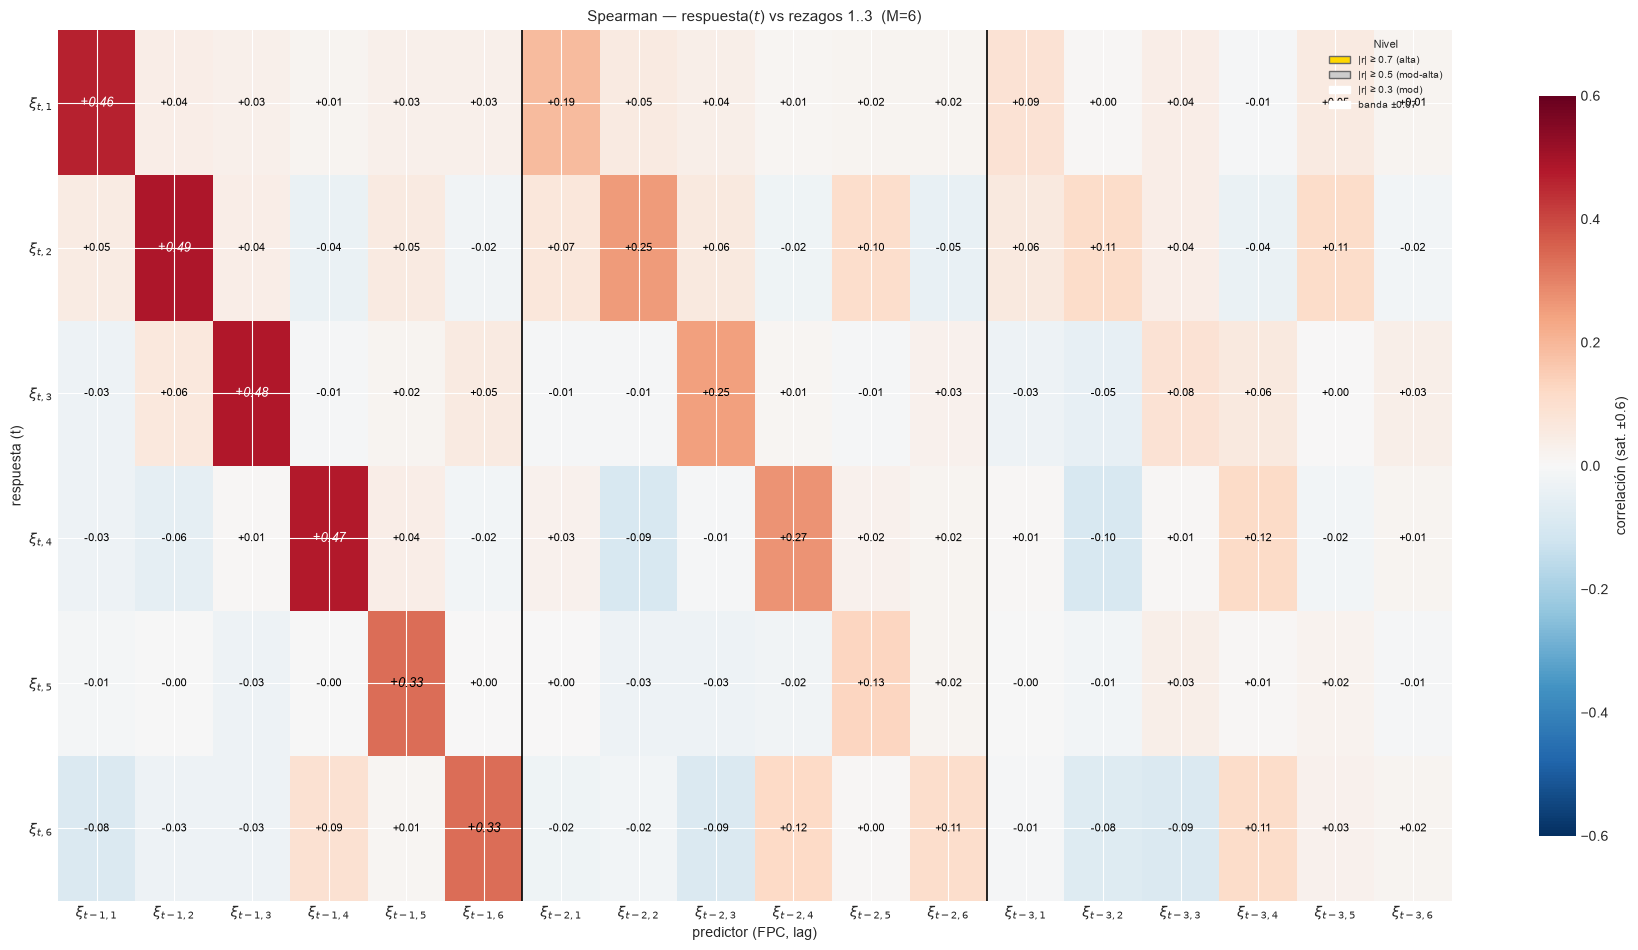

,n_test,RMSE_fpc1,RMSE_fpc2,RMSE_fpc3,RMSE_fpc4,RMSE_fpc5,RMSE_fpc6,RMSE_scores_prom,R2_scores_prom,MISE,RMSE_funcional
modelo,,,,,,,,,,,
media_incondicional,300.0000,0.6349,0.5512,0.3878,0.2718,0.2082,0.1563,0.3684,-0.0087,1.0277,1.0138
persistencia_lag1,300.0000,0.6931,0.5803,0.3588,0.2816,0.2431,0.1847,0.3903,-0.1750,1.1472,1.0711


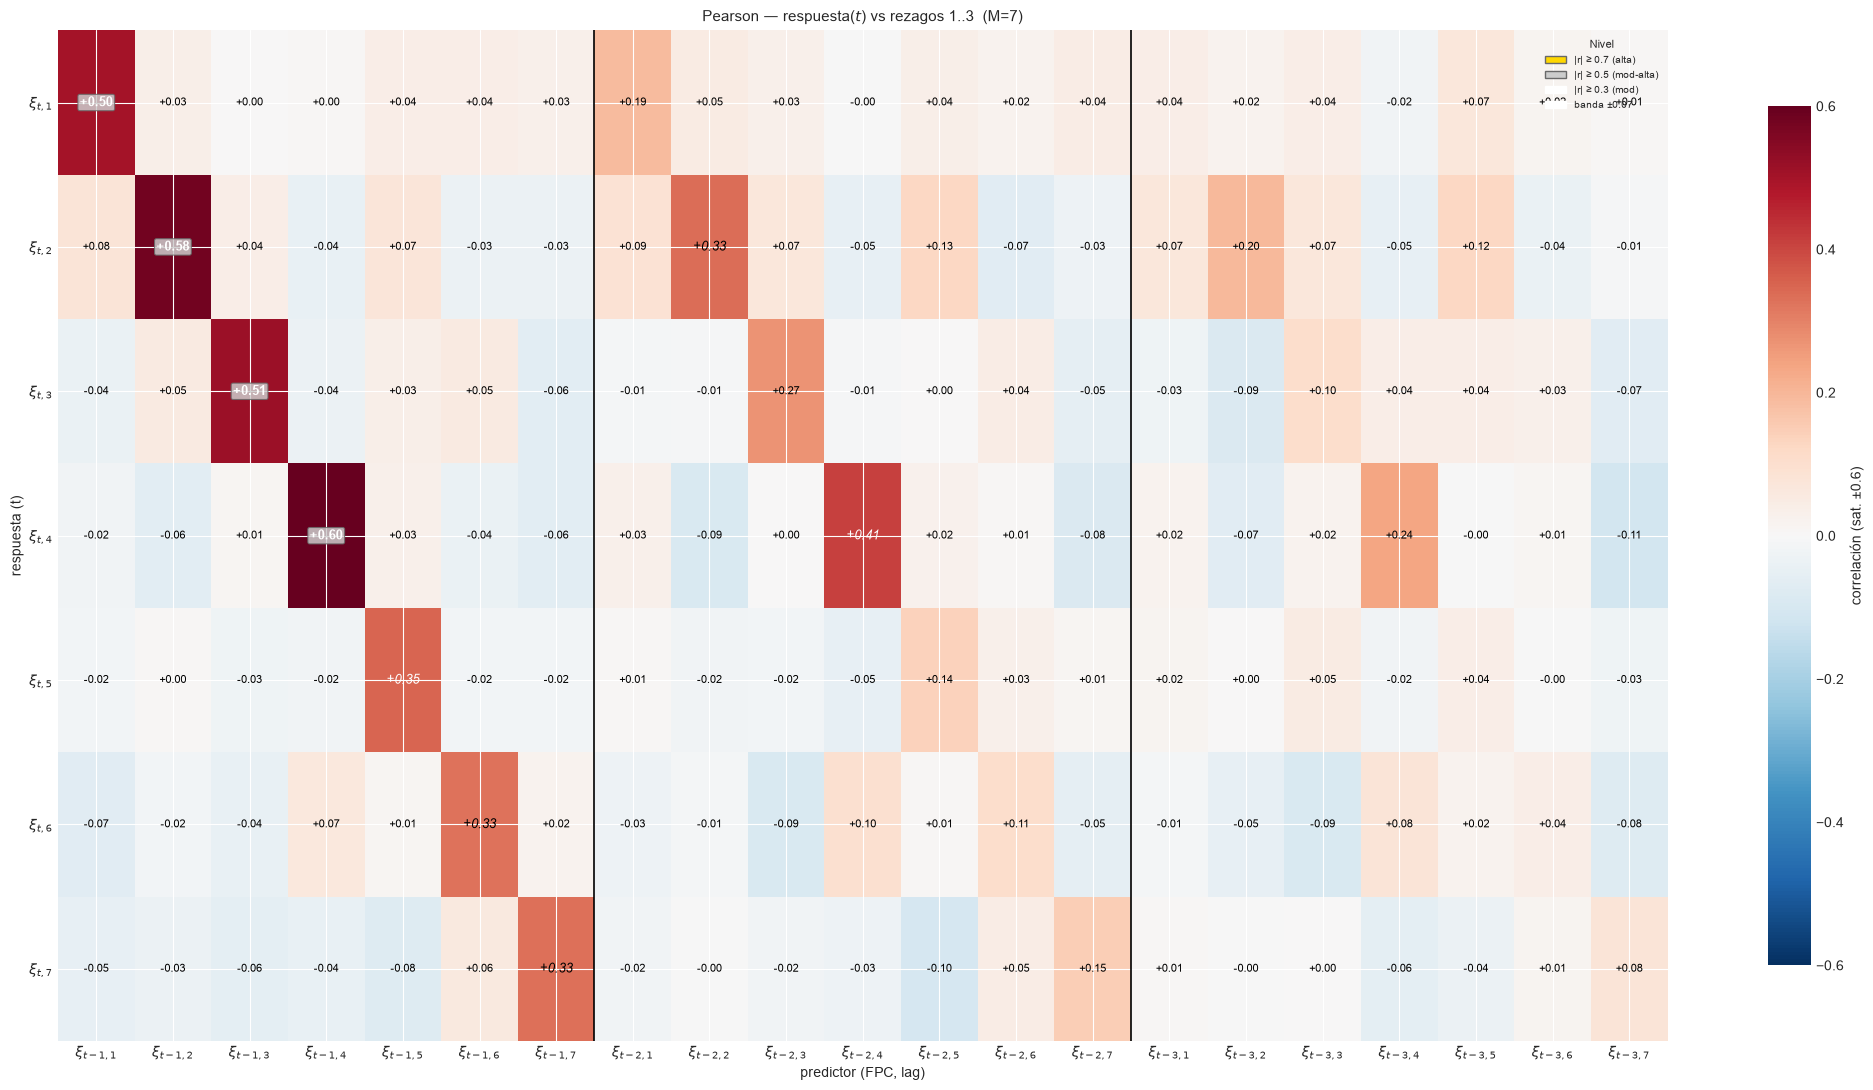

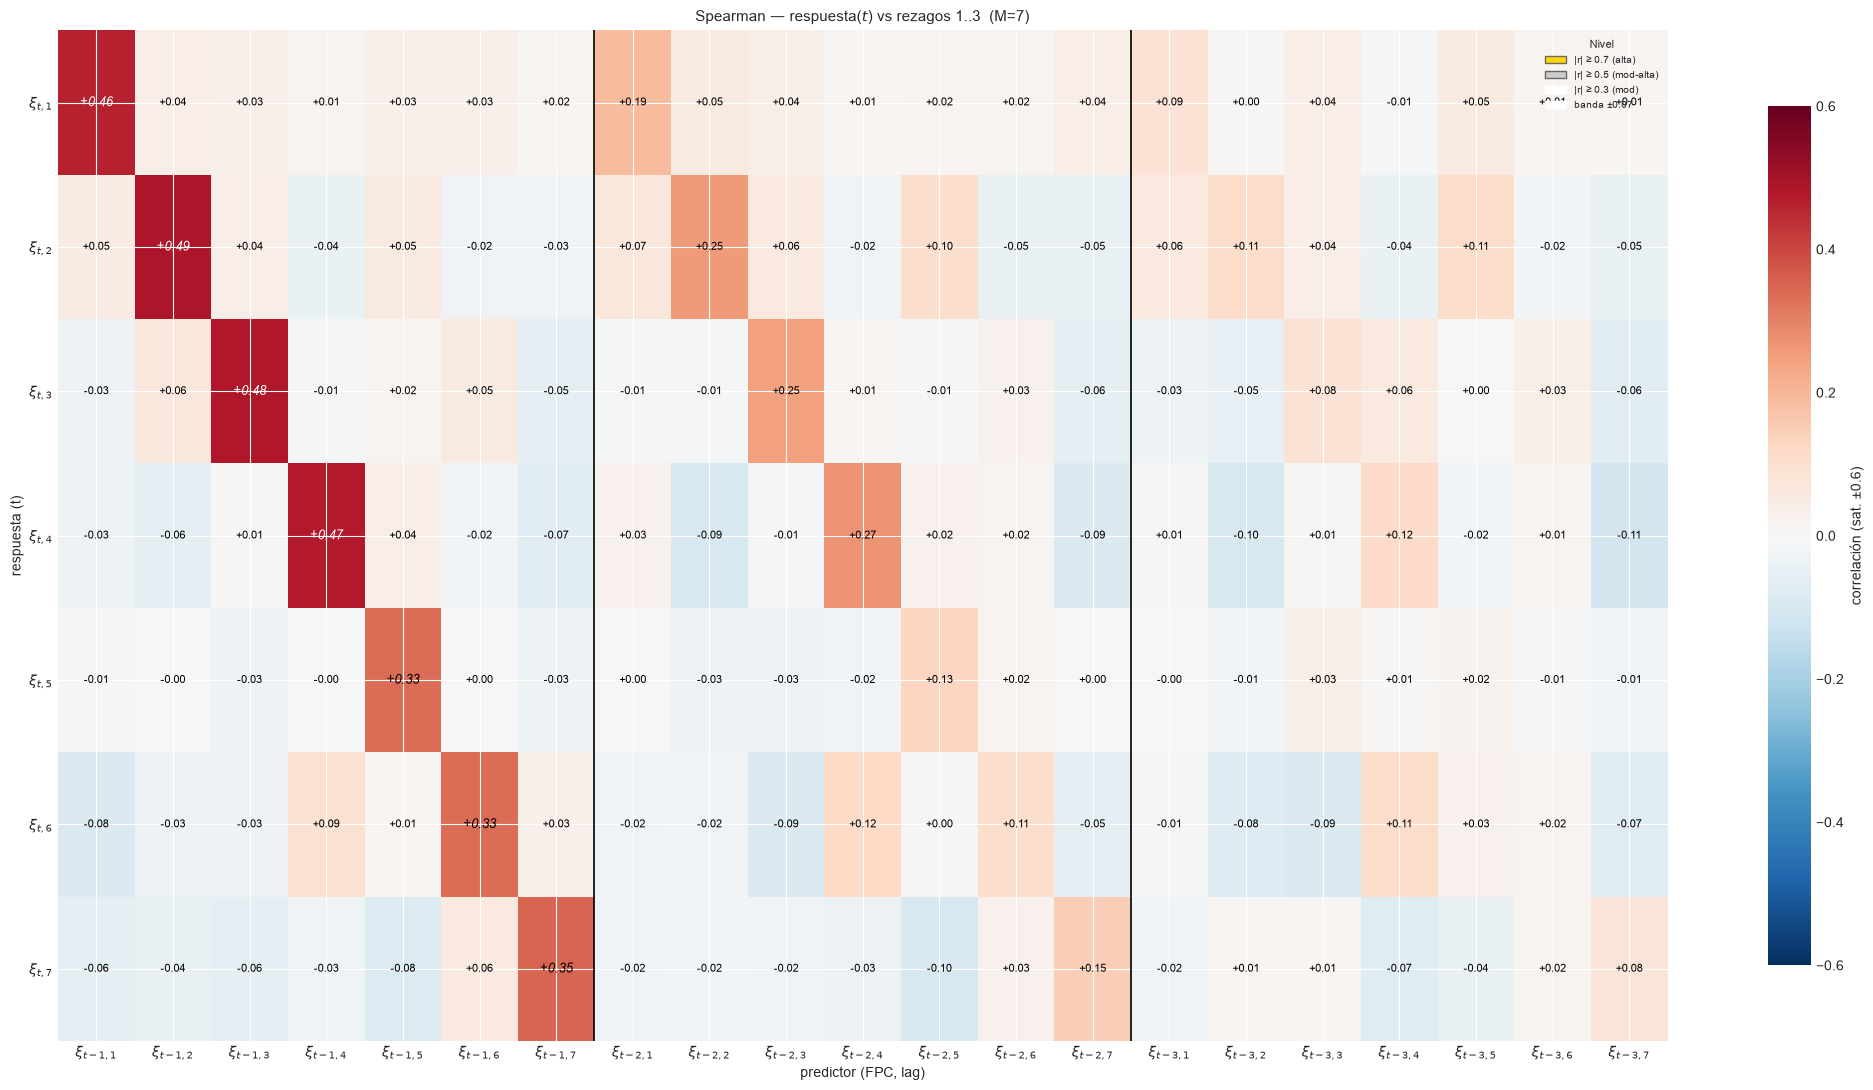

,n_test,RMSE_fpc1,RMSE_fpc2,RMSE_fpc3,RMSE_fpc4,RMSE_fpc5,RMSE_fpc6,RMSE_fpc7,RMSE_scores_prom,R2_scores_prom,MISE,RMSE_funcional
modelo,,,,,,,,,,,,
media_incondicional,300.0000,0.6349,0.5512,0.3878,0.2718,0.2082,0.1563,0.1205,0.3329,-0.0078,1.0277,1.0138
persistencia_lag1,300.0000,0.6931,0.5803,0.3588,0.2816,0.2431,0.1847,0.1406,0.3546,-0.2021,1.1525,1.0735


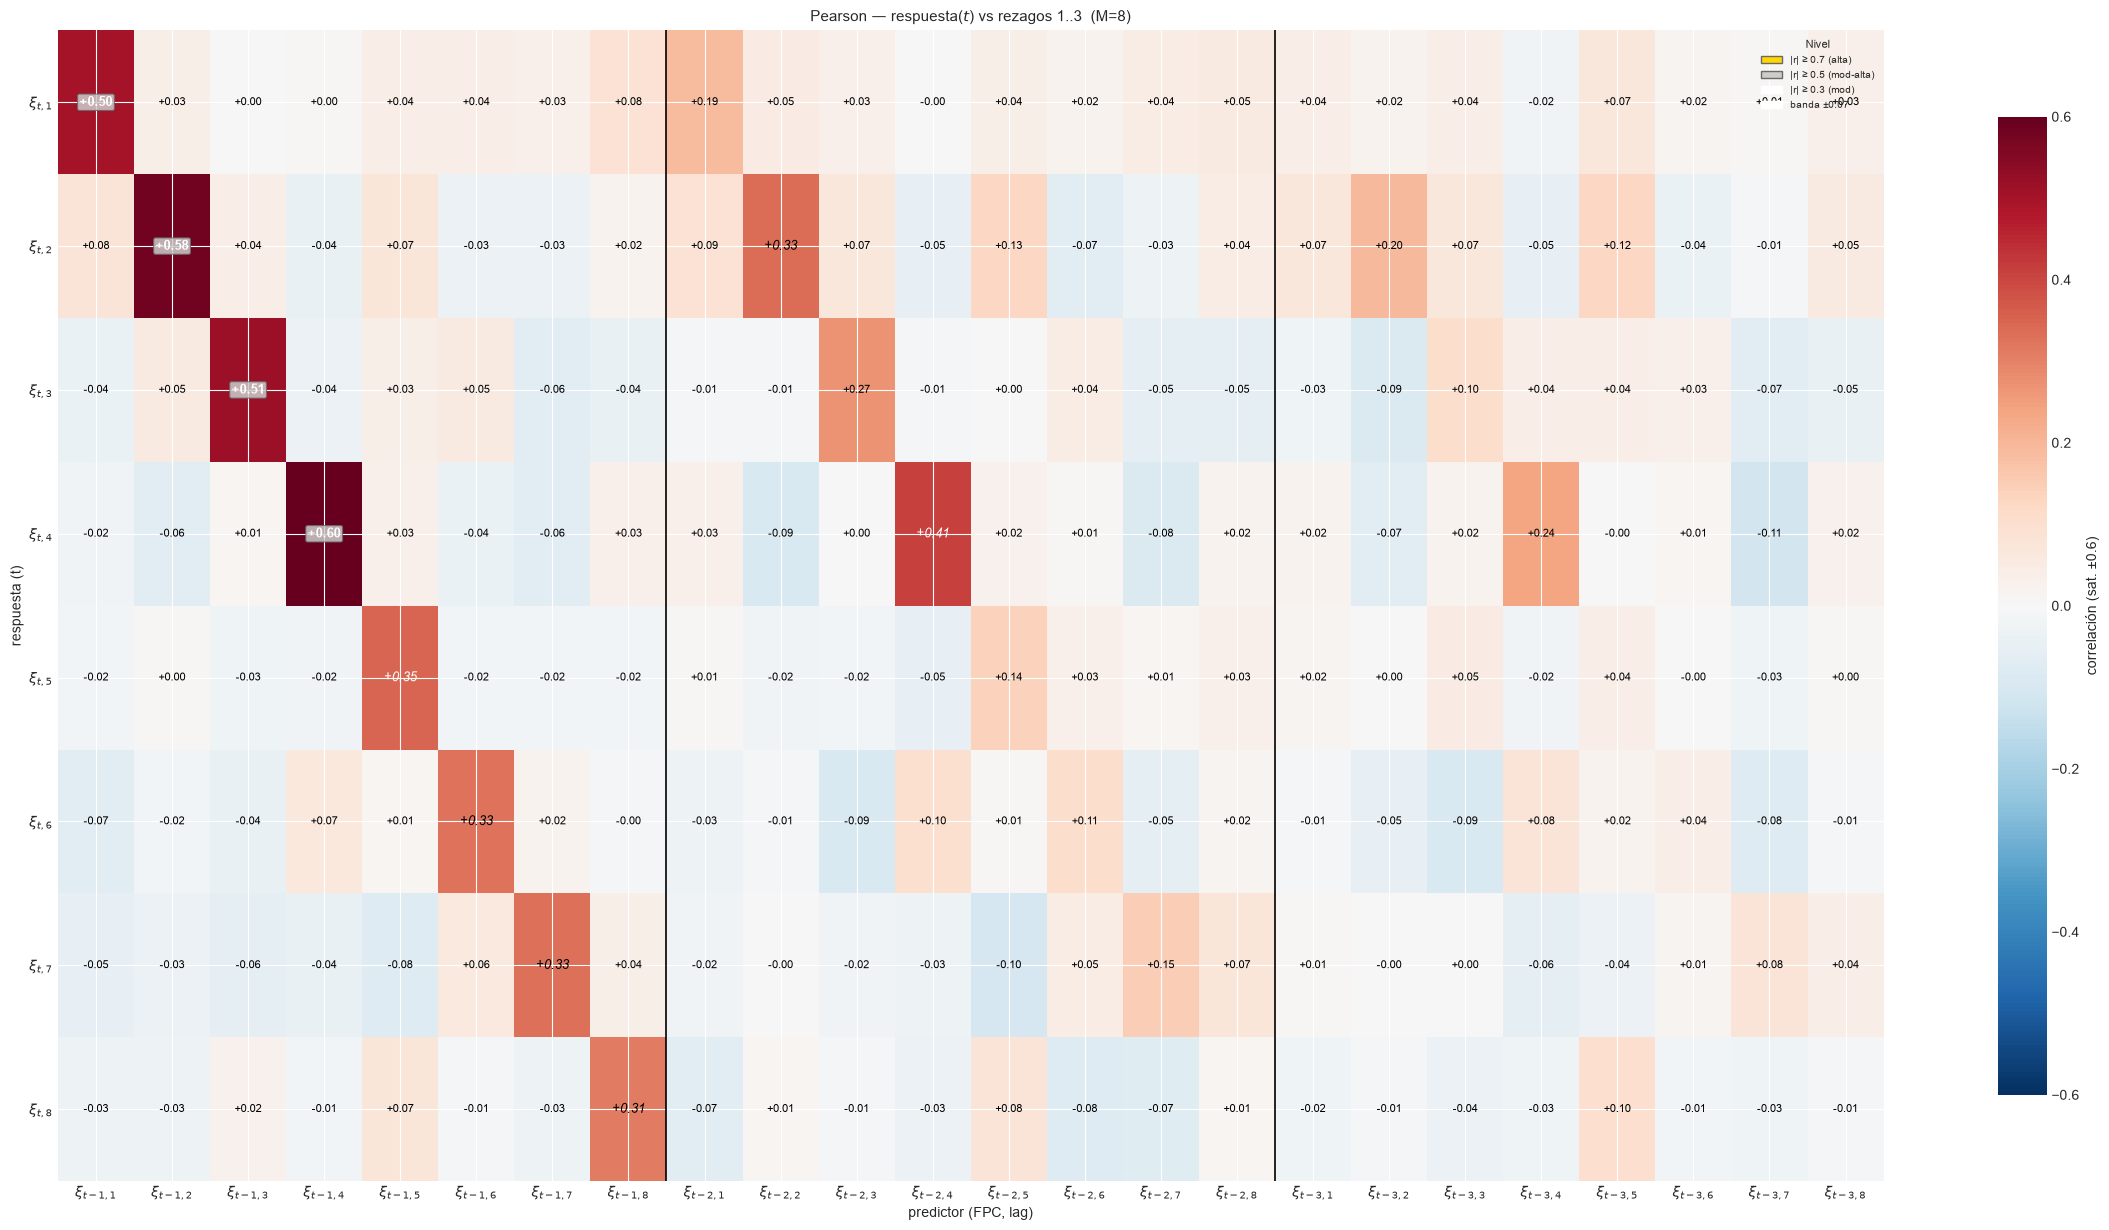

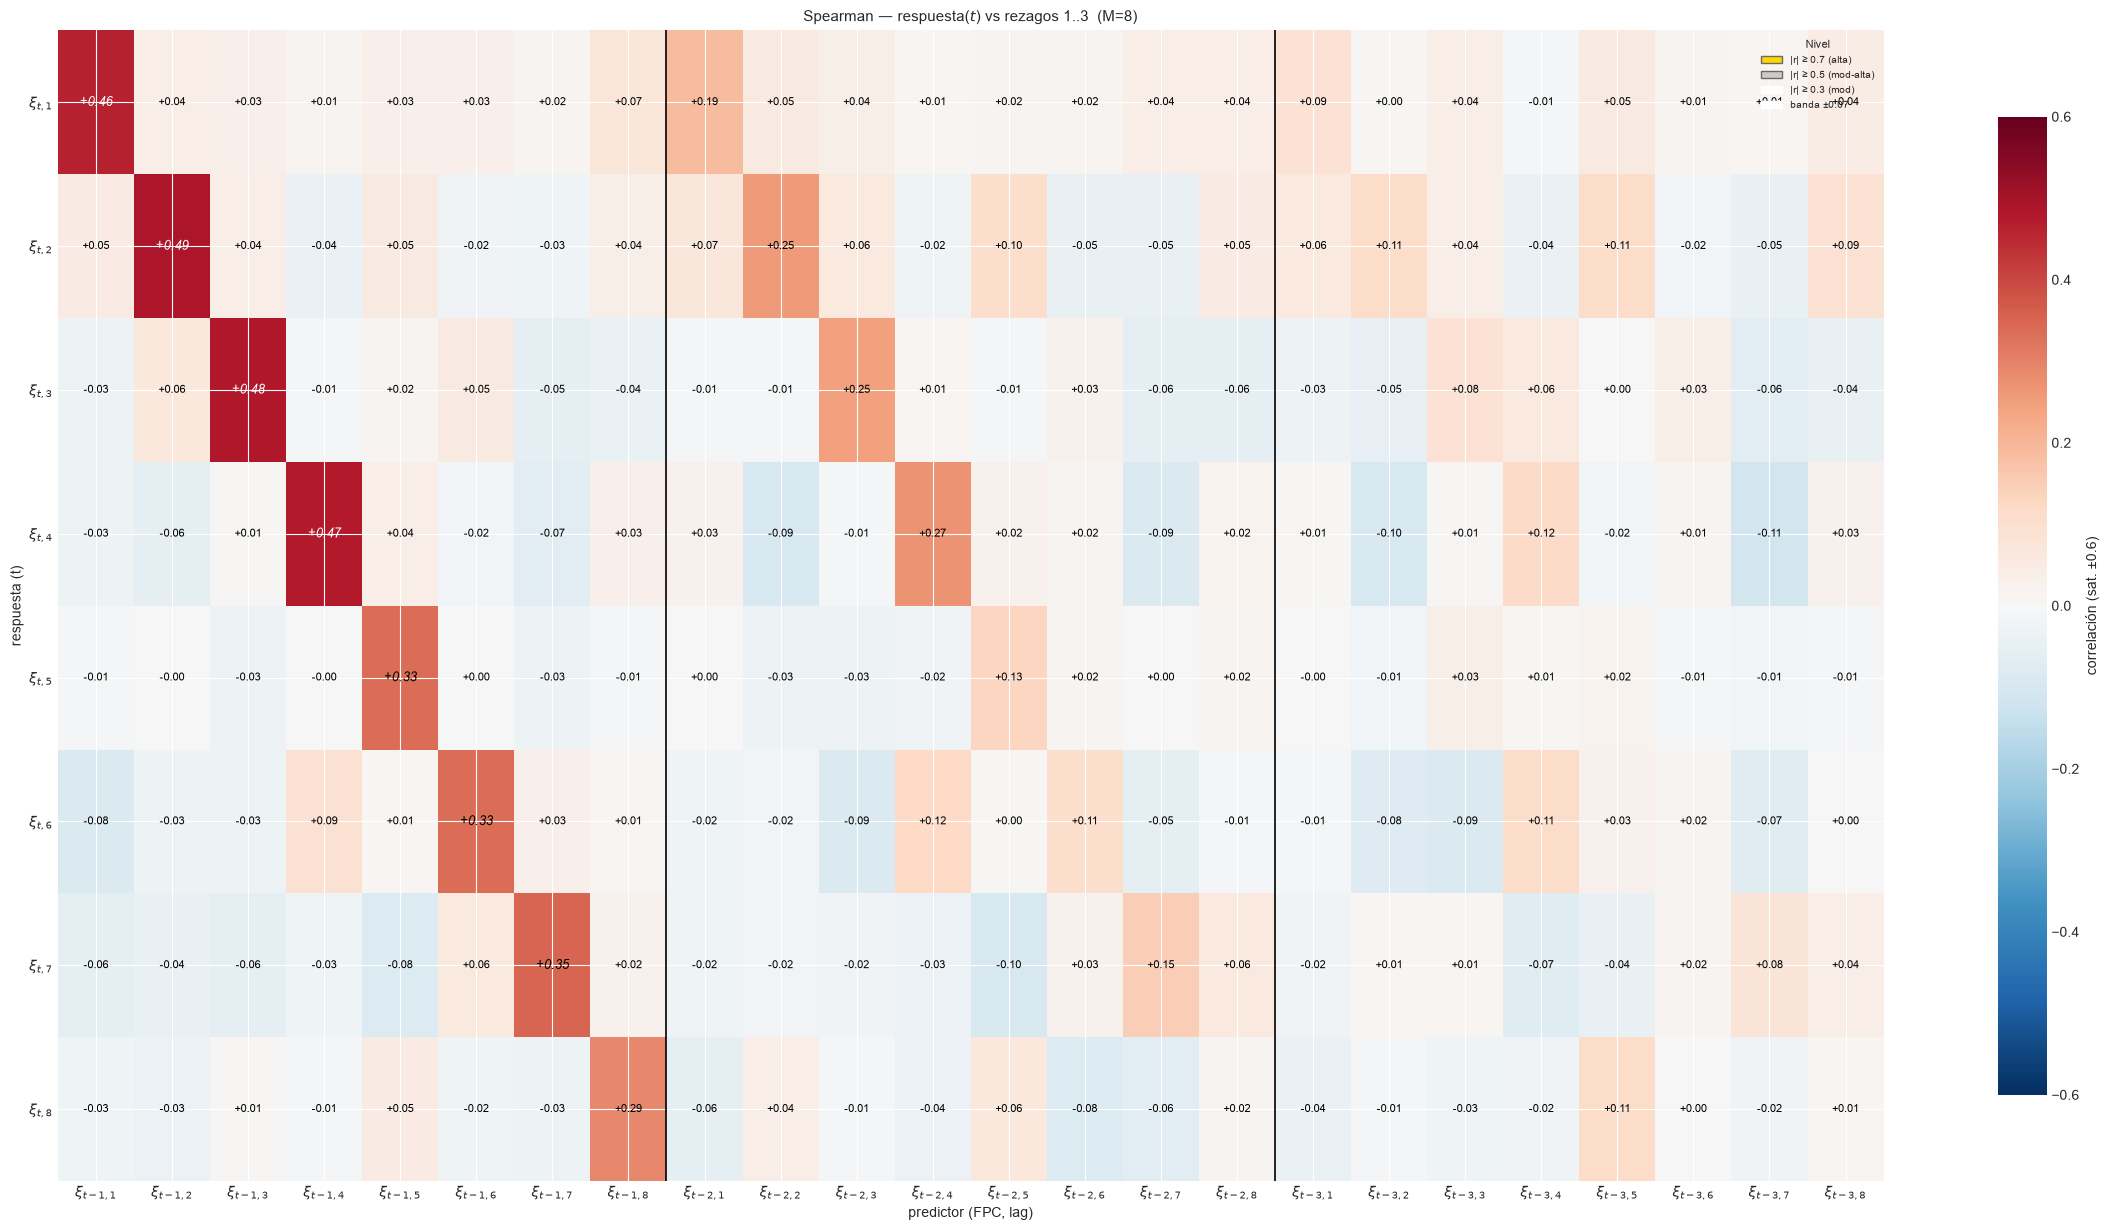

,n_test,RMSE_fpc1,RMSE_fpc2,RMSE_fpc3,RMSE_fpc4,RMSE_fpc5,RMSE_fpc6,RMSE_fpc7,RMSE_fpc8,RMSE_scores_prom,R2_scores_prom,MISE,RMSE_funcional
modelo,,,,,,,,,,,,,
media_incondicional,300.0000,0.6349,0.5512,0.3878,0.2718,0.2082,0.1563,0.1205,0.0873,0.3022,-0.0077,1.0277,1.0138
persistencia_lag1,300.0000,0.6931,0.5803,0.3588,0.2816,0.2431,0.1847,0.1406,0.1019,0.3230,-0.2232,1.1552,1.0748


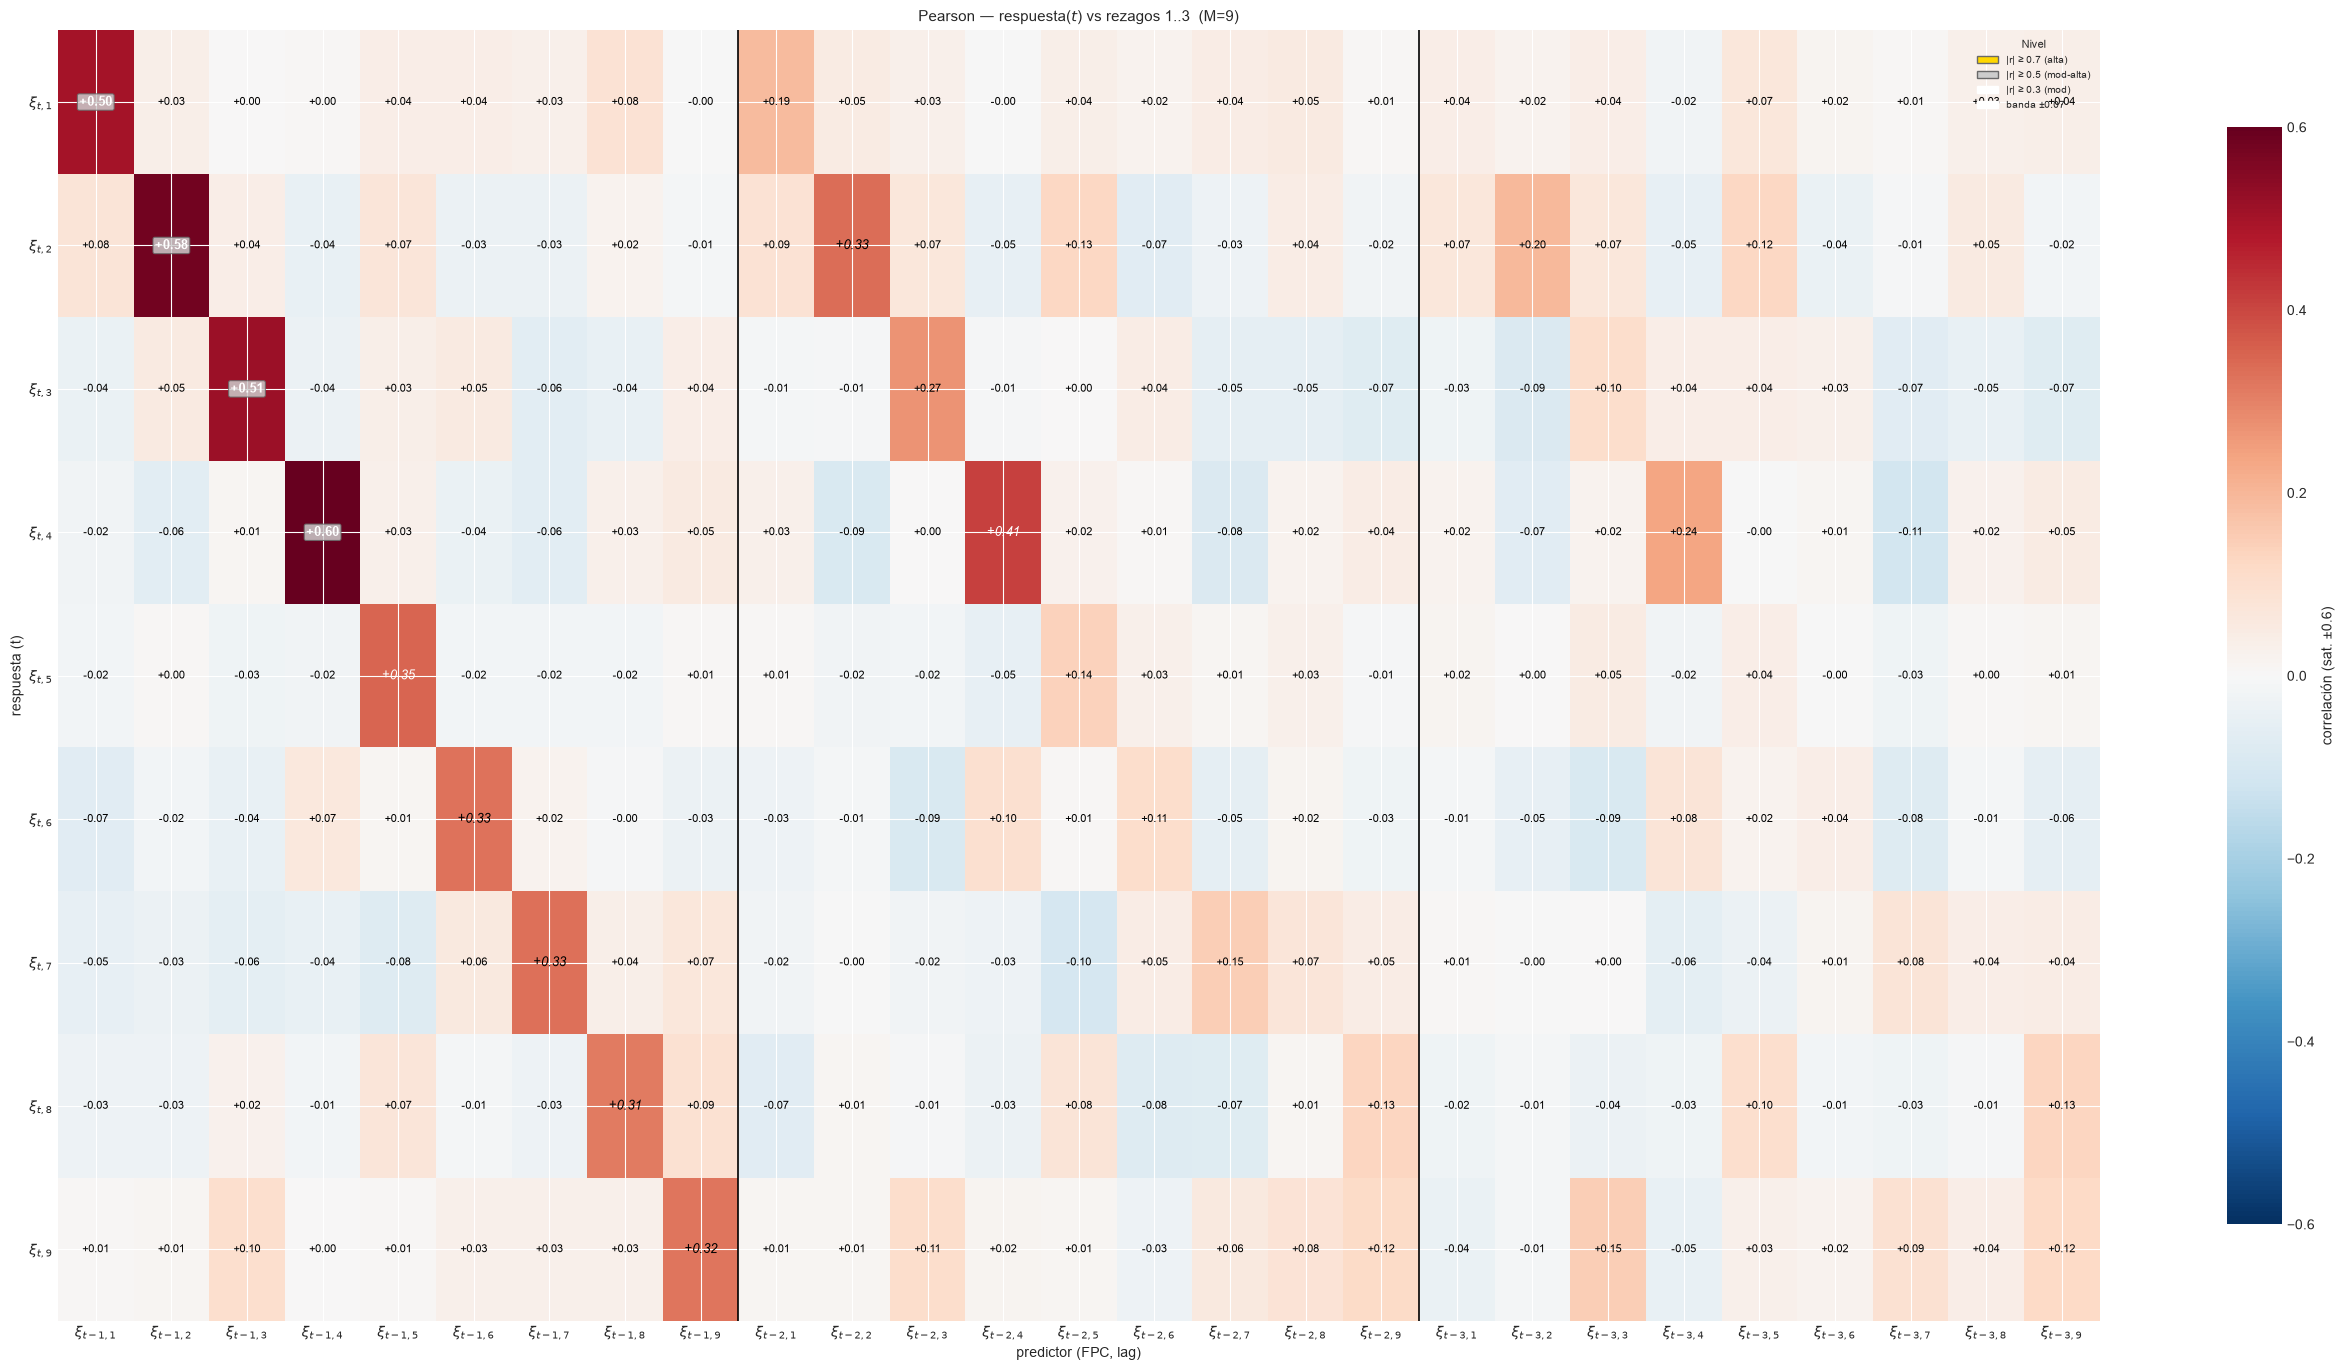

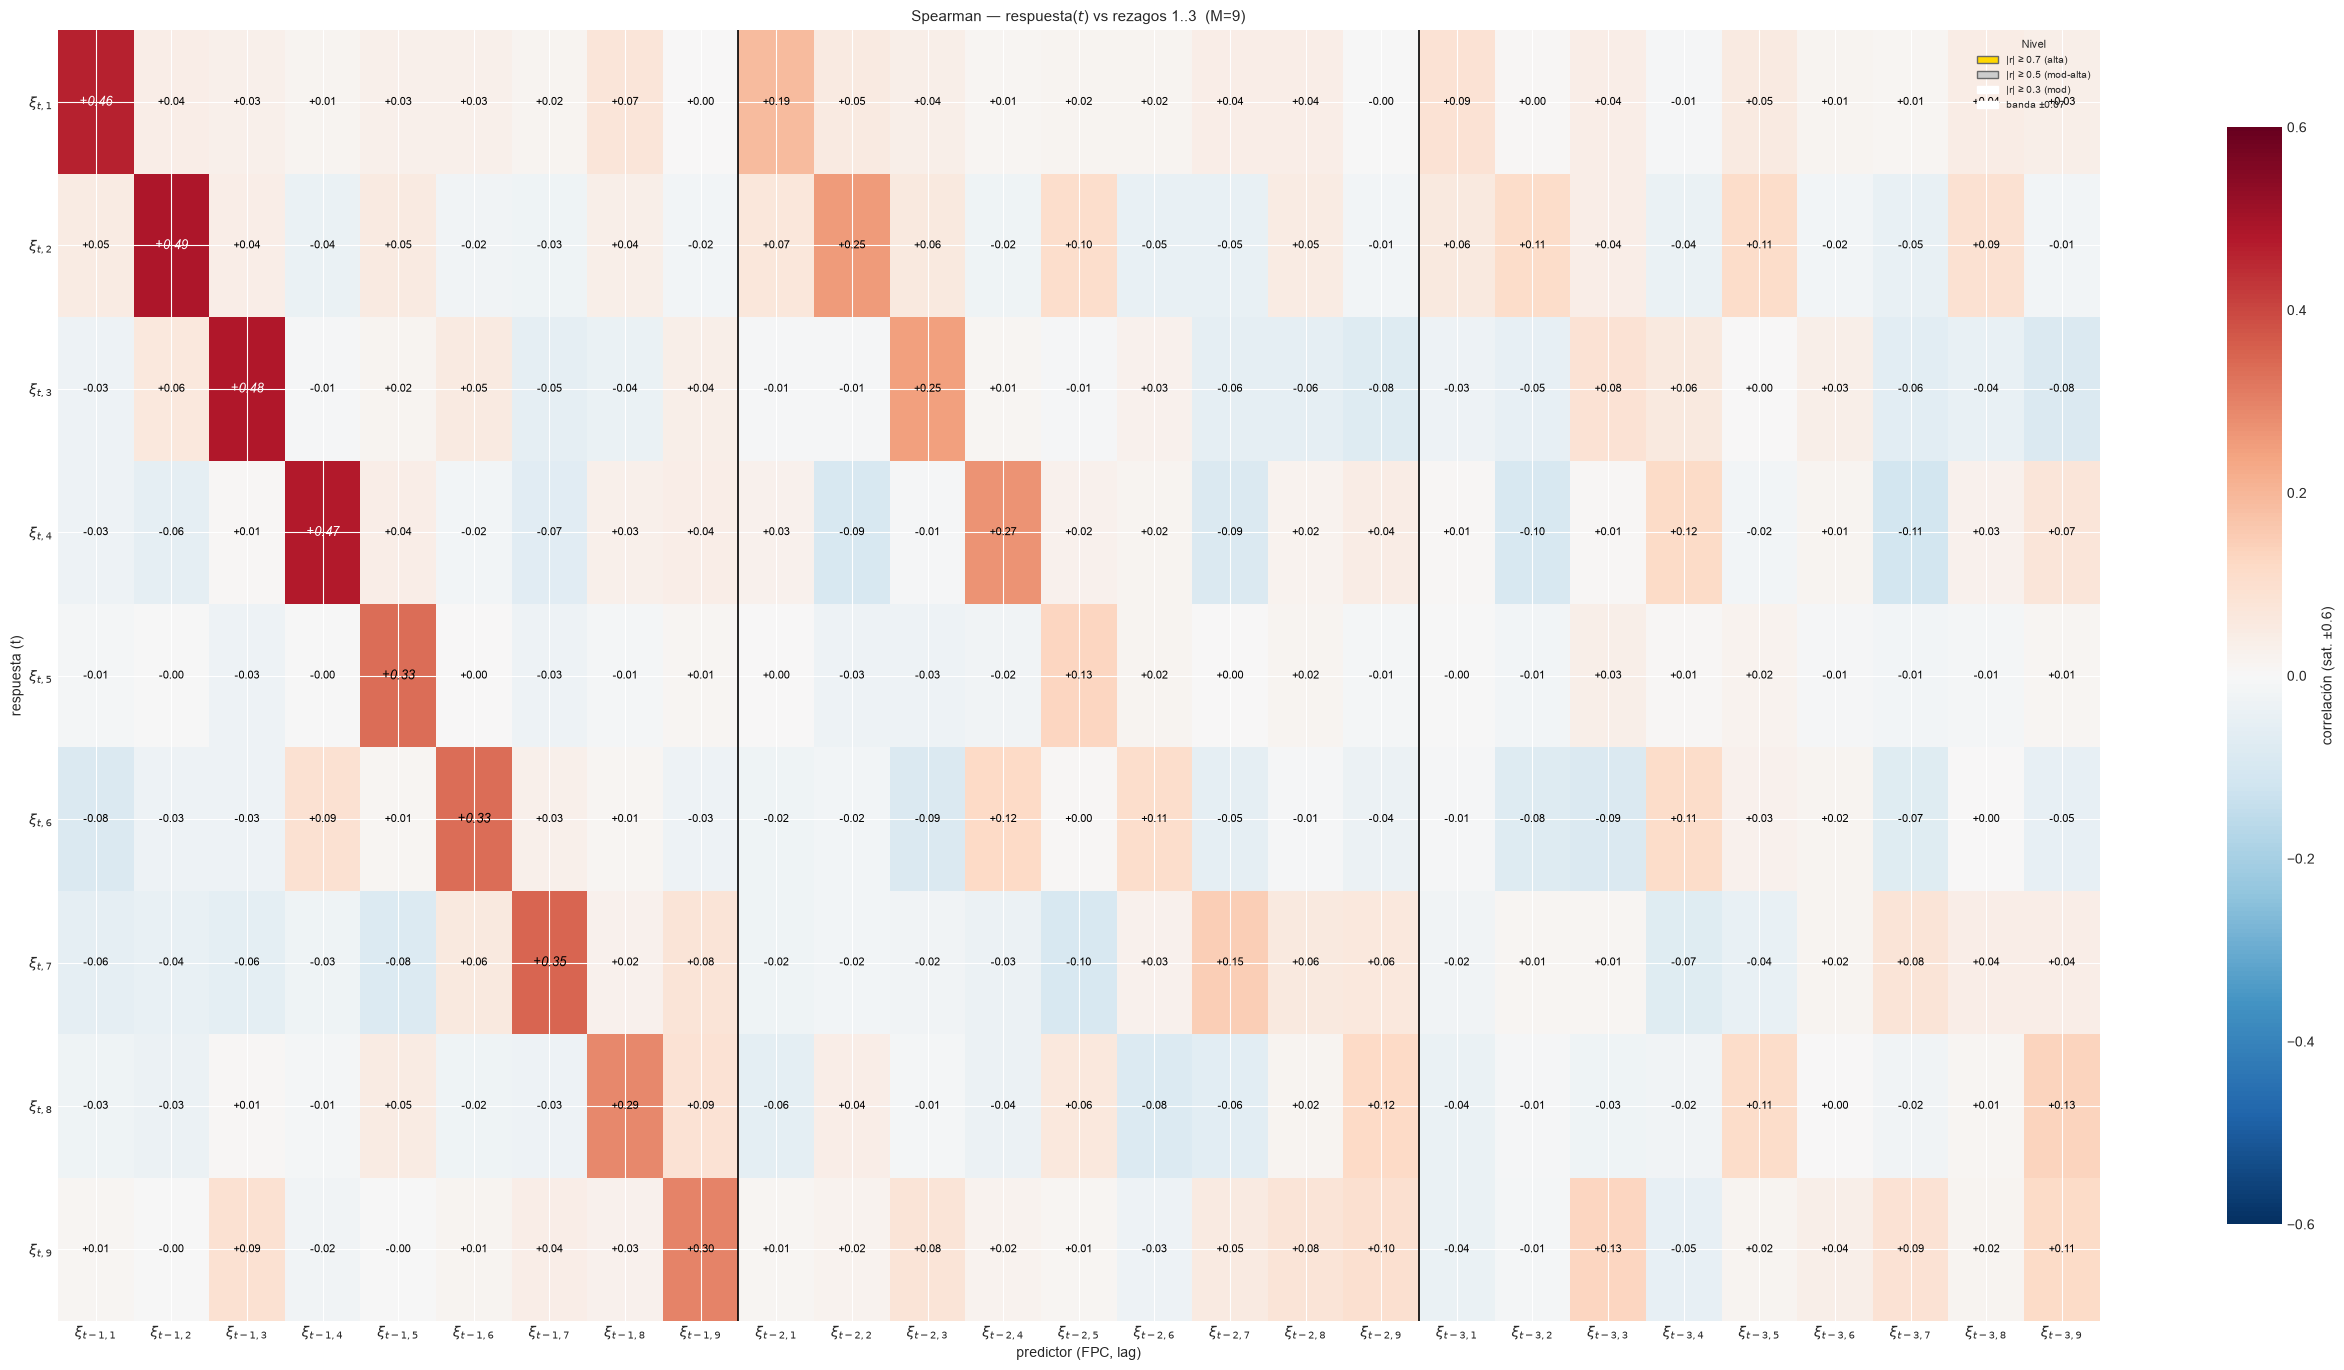

,n_test,RMSE_fpc1,RMSE_fpc2,RMSE_fpc3,RMSE_fpc4,RMSE_fpc5,RMSE_fpc6,RMSE_fpc7,RMSE_fpc8,RMSE_fpc9,RMSE_scores_prom,R2_scores_prom,MISE,RMSE_funcional
modelo,,,,,,,,,,,,,,
media_incondicional,300.0000,0.6349,0.5512,0.3878,0.2718,0.2082,0.1563,0.1205,0.0873,0.0665,0.2760,-0.0070,1.0277,1.0138
persistencia_lag1,300.0000,0.6931,0.5803,0.3588,0.2816,0.2431,0.1847,0.1406,0.1019,0.0812,0.2961,-0.2531,1.1574,1.0758


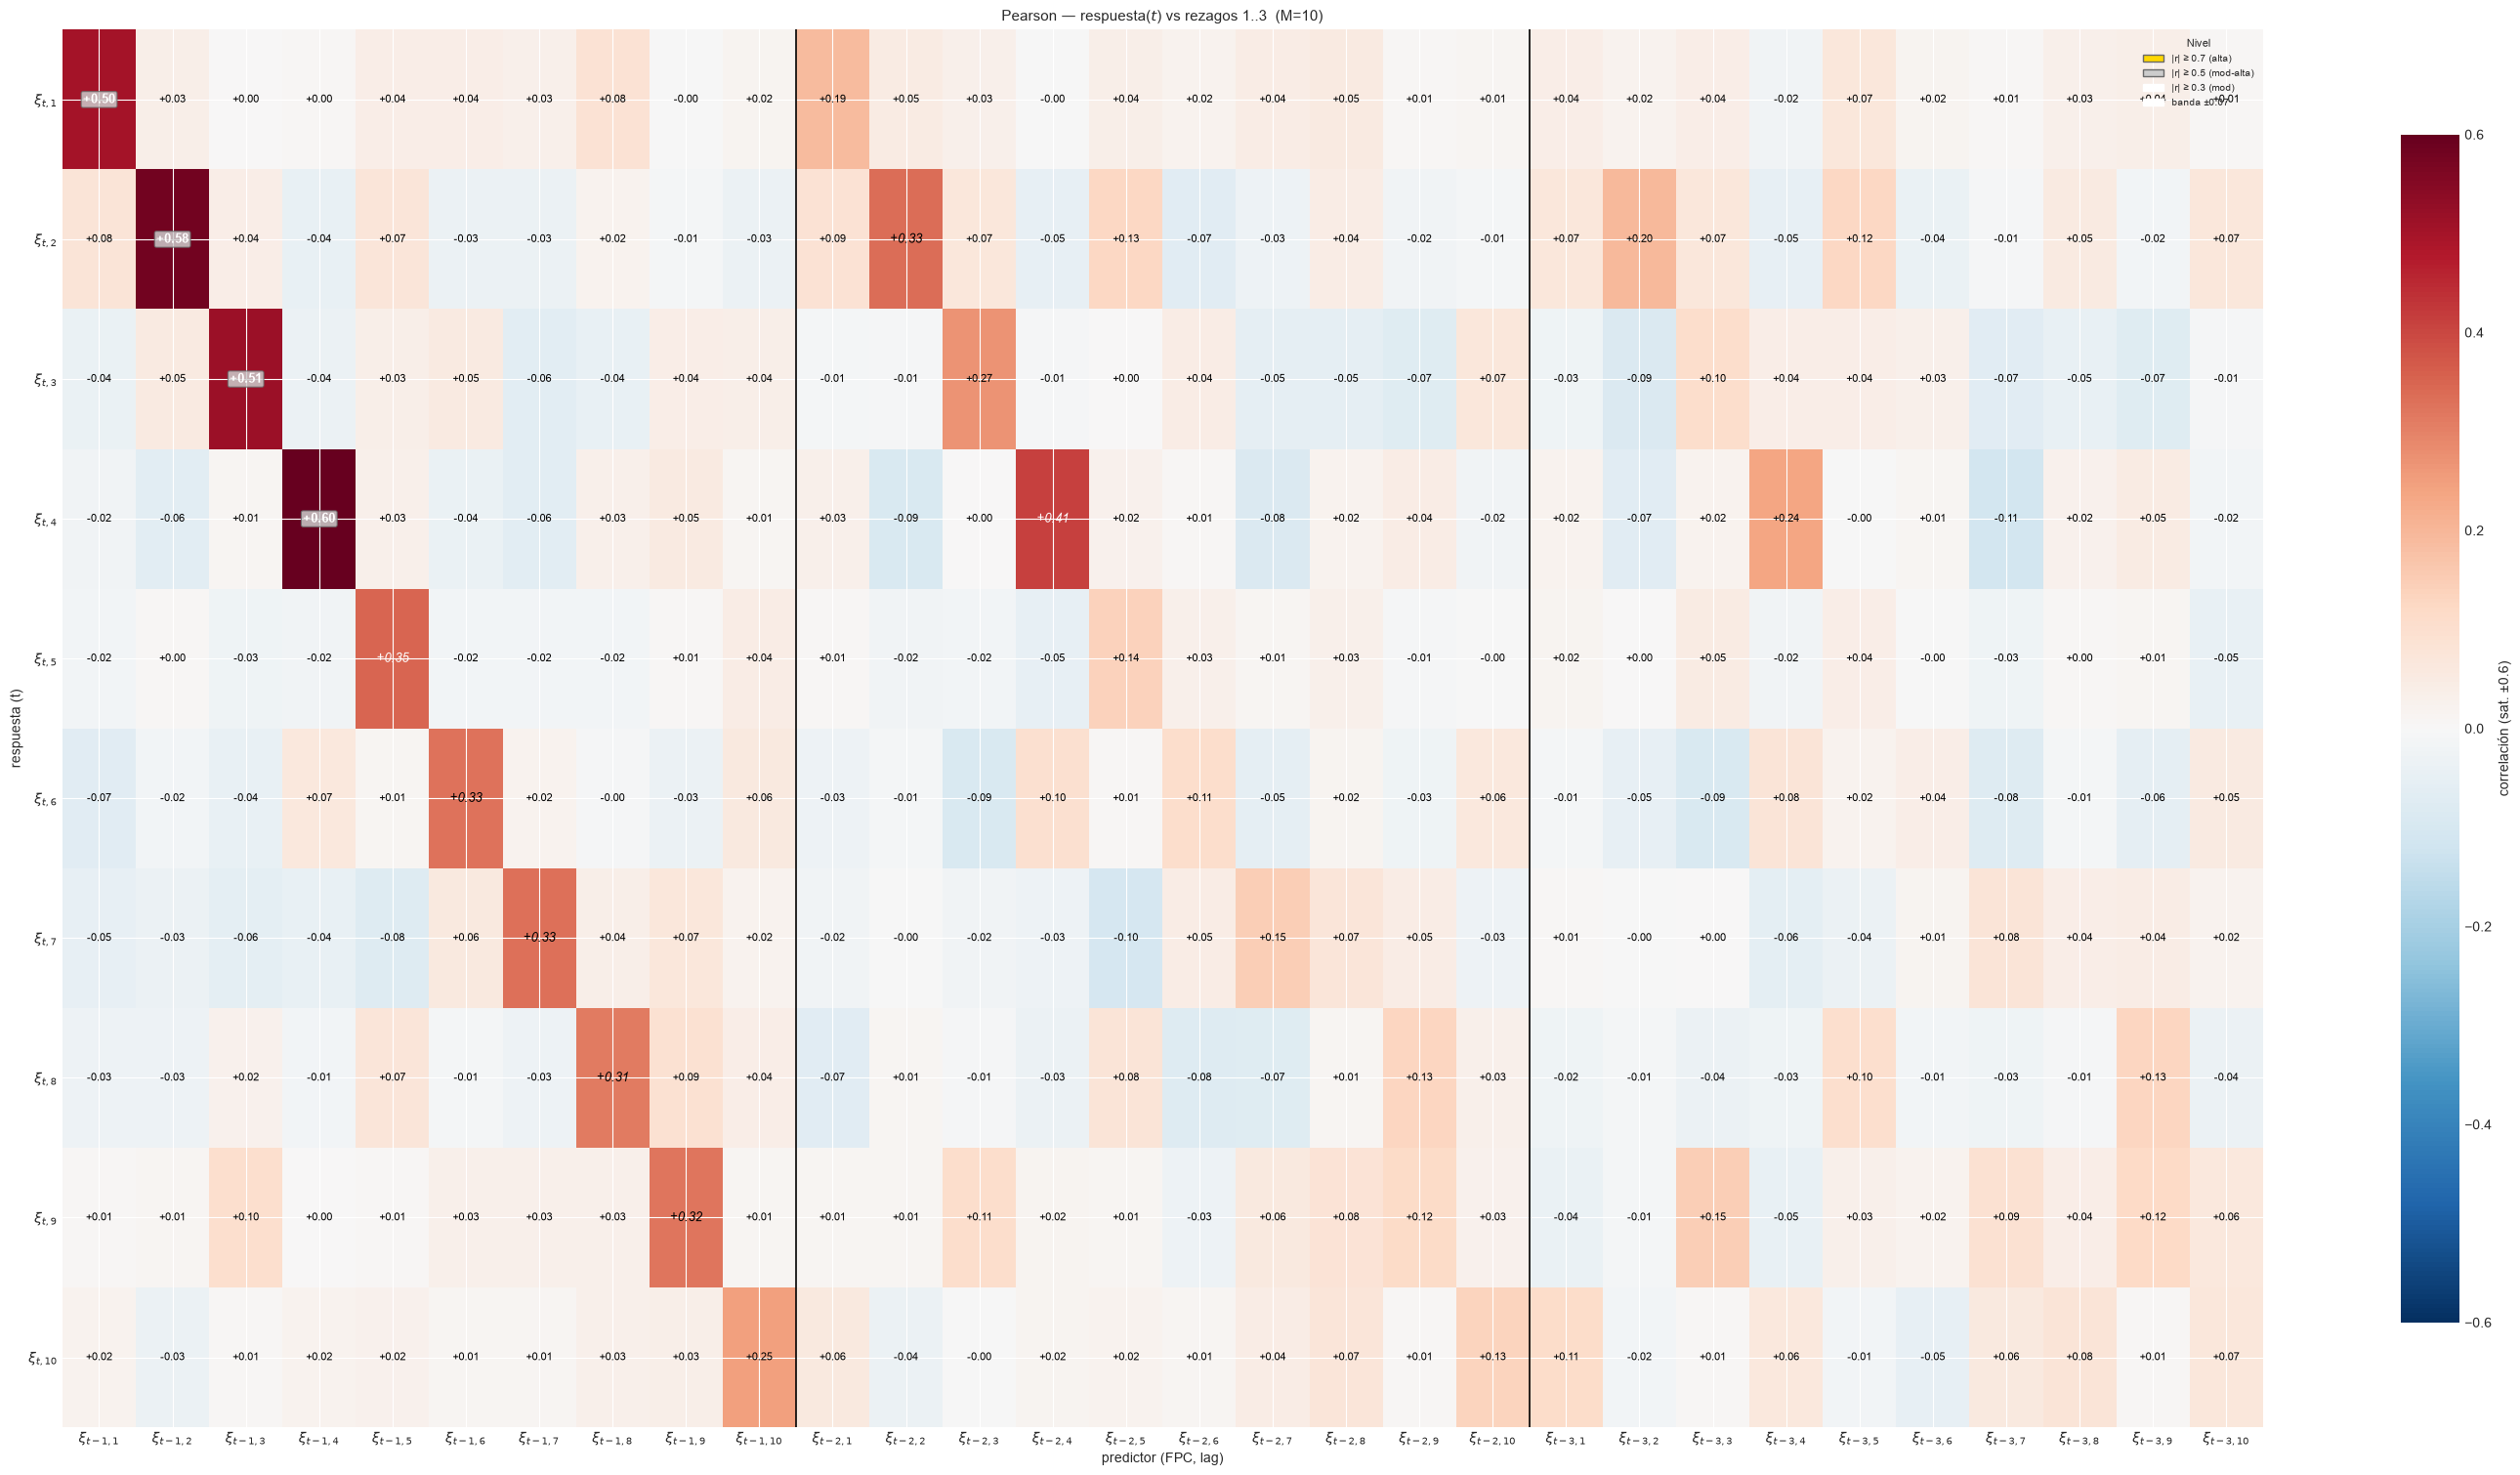

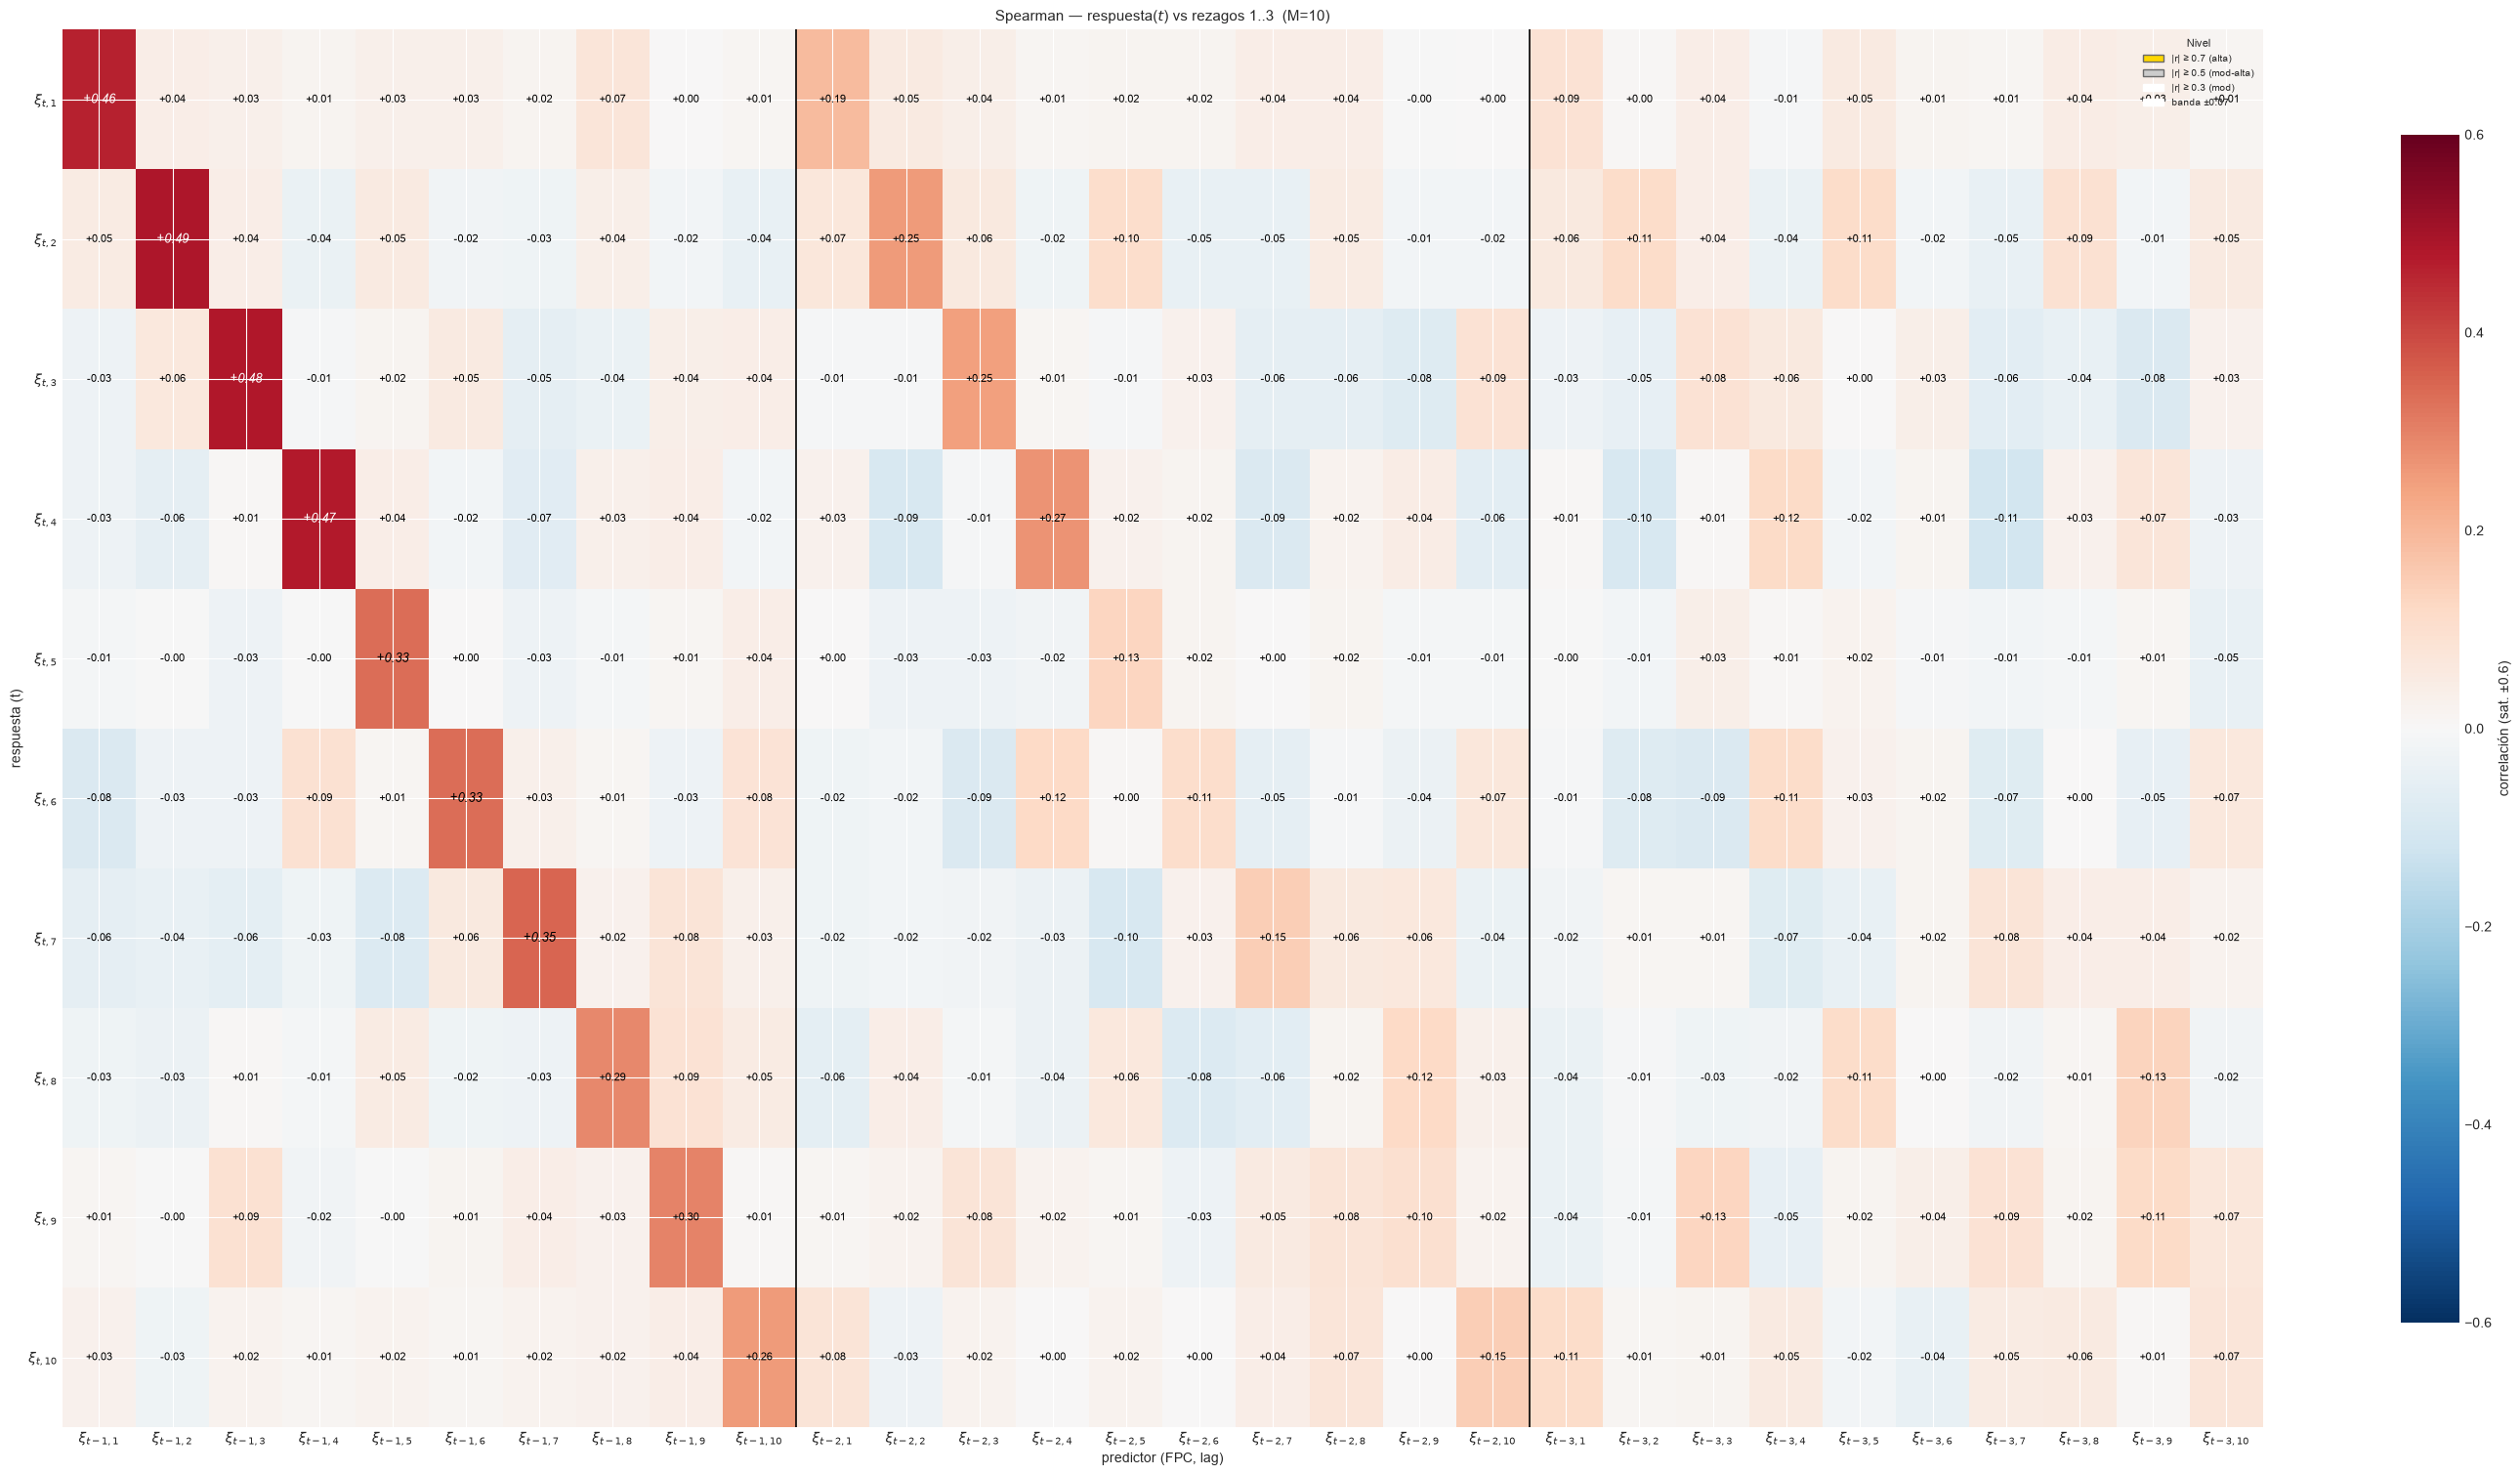

,n_test,RMSE_fpc1,RMSE_fpc2,RMSE_fpc3,RMSE_fpc4,RMSE_fpc5,RMSE_fpc6,RMSE_fpc7,RMSE_fpc8,RMSE_fpc9,RMSE_fpc10,RMSE_scores_prom,R2_scores_prom,MISE,RMSE_funcional
modelo,,,,,,,,,,,,,,,
media_incondicional,300.0000,0.6349,0.5512,0.3878,0.2718,0.2082,0.1563,0.1205,0.0873,0.0665,0.0479,0.2532,-0.0069,1.0277,1.0138
persistencia_lag1,300.0000,0.6931,0.5803,0.3588,0.2816,0.2431,0.1847,0.1406,0.1019,0.0812,0.0558,0.2721,-0.2641,1.1582,1.0762


In [24]:
# Diagnóstico de rezagos (sólo train) y líneas base a h=1, por punto del barrido.
for r in RESUMEN:
    plot_diagnostico_rezagos(r["diagnostico_rezagos"], r["M"], PATHS_POR_M[r["M"]]["out_report"])
    plt.show()
    display(r["baselines"].style.format("{:.4f}", na_rep="-")
            .set_caption(f"Líneas base (M={r['M']}) — prueba, h=1, contra la curva SUAVIZADA"))

## 5. Resumen del barrido

In [25]:
resumen_df = pd.DataFrame(RESUMEN).set_index("M")
display(resumen_df[["experiment_id", "var_acum", "K", "coincide_regla_95",
                    "n_components", "p_covariables", "contrato_ok"]]
        .style.format({"var_acum": "{:.4%}"})
        .set_caption(f"Barrido en M · {EXPERIMENT_BASE} · "
                     f"K disponible = {resumen_df['K'].iloc[0]}"))

_fallidos = [r for r in RESUMEN if not r["contrato_ok"]]
for r in _fallidos:
    print(f"\n[FALLA] M={r['M']} ({r['experiment_id']}):")
    for p in r["problemas"]:
        print(f"  - {p}")
assert not _fallidos, (
    f"El contrato falla en M = {[r['M'] for r in _fallidos]}. No lanzar MATLAB: "
    f"psbp_fd_iteracion.m leería artefactos inconsistentes.")

print(f"\n{'='*70}\nListo. Siguiente paso, en MATLAB desde esta carpeta:\n"
      f"  >> psbp_fd_iteracion\n"
      + (f"con M_FPCA_LIST = {list(M_FPCA_LIST)}   (cruzados: se entrena CADA M)\n"
         if CRUZADOS else
         f"con M_FPCA_LIST = [{M_ENTRENO}]   (solo se entrena M={M_ENTRENO}: "
         f"los M menores reutilizan sus trazas)\n")
      + f"Antes, correr este notebook con cada VARIANTE de {list(VARIANTES)}.\n{'='*70}")

,experiment_id,var_acum,K,coincide_regla_95,n_components,p_covariables,contrato_ok
M,,,,,,,
1,escenario_201_chungEscG_1_r01_m01,38.2736%,10,False,1,4,True
2,escenario_201_chungEscG_1_r01_m02,67.1473%,10,False,2,4,True
3,escenario_201_chungEscG_1_r01_m03,80.8462%,10,False,3,4,True
4,escenario_201_chungEscG_1_r01_m04,90.5960%,10,False,4,4,True
5,escenario_201_chungEscG_1_r01_m05,95.1228%,10,True,5,4,True
6,escenario_201_chungEscG_1_r01_m06,97.4358%,10,False,6,4,True
7,escenario_201_chungEscG_1_r01_m07,98.6813%,10,False,7,4,True
8,escenario_201_chungEscG_1_r01_m08,99.3628%,10,False,8,4,True
9,escenario_201_chungEscG_1_r01_m09,99.7909%,10,False,9,4,True



Listo. Siguiente paso, en MATLAB desde esta carpeta:
  >> psbp_fd_iteracion
con M_FPCA_LIST = [10]   (solo se entrena M=10: los M menores reutilizan sus trazas)
Antes, correr este notebook con cada VARIANTE de ['chungEscG', 'chungEsc'].
